# Classification of Exoplanets/False Positives Using Machine Learning and Python.

![alt text](Hr8799_orbit_hd.gif)

### Introduction to this dataset:

Exoplanetary science has made a long way, and now, with more than 6.000 exoplanets discovered, the data starts to become more and more significant. In this notebook, I wanted to give a brief solution to this problem: “How can we distinguish real planets from False Positives?” This has the practicality of being able to create a first scan of a possible dataset in the future, and to help researchers organize their target list.

In [57]:
#import of standard libraries
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [58]:
#Download the data
df = pd.read_csv("Transits_data.csv")

### Brief dataset description:

This dataset was created by analyzing open-source datasets from NASA’s Exoplanet Archive, specifically those from the TESS mission. It’s comprised of more than 7,000 observations; unfortunately, most of them are Planet candidates, therefore, they don’t have a label. The observations are only transit-based and have no light curve associated with them.

The features of this dataset are:

1. TOI: the ID of the planet
2. Label: 0 for False positive exoplanets, 1 for confirmed/known exoplanets
3. Orbital_period: The orbital period of the planet, or how much time in days it takes the planet to orbit the star
4. Transit_duration: how much time in hours does the planet spend obscuring the star
5. Transit_depth: the measure of how much the planet obscures the star.
6. Planet_radius: The measured radius of the planet from the transit, measured in Earth radii
7. Planet_equilibrium_temperature: the equilibrium temperature on the surface of the planet in Kelvin
8. Magnitude: TESS measured the apparent magnitude, or how bright the star is as seen from Earth
9. Stellar_temperature: Superficial temperature of the star measured in Kelvin
10. Stellar_radius: the star radius in Solar radii

### The scales of the features:

These features: Orbital_period, Transit_duration, Transit_depth, Planet_radius, Planet_equilibrium_temperature, Stellar_temperature, and Stellar_radius need to be log-scaled because they include extreme values.

In [59]:
df.head() #visualize the dataset

,Toi,Label,Orbital_period,Transit_duration,Transit_depth,Planet_radius,Planet_equilibrium_temperature,Magnitude,Stellar_temperature,Stellar_radius
0,1000.01,0,2.171348,2.01722,656.886099,5.818163,3127.204052,9.604000,10249.0,2.16986
1,1002.01,0,1.867557,1.40800,1500.000000,23.752900,2037.000000,9.299501,8924.0,5.73000
2,1003.01,0,2.743230,3.16700,383.410000,NaN,1631.000000,9.300300,5388.5,NaN
3,1004.01,0,3.573014,3.37000,755.000000,11.311300,4260.000000,9.135500,9219.0,2.15000
4,1005.01,0,4.550594,2.65400,3731.000000,7.108410,1257.000000,9.130900,5613.0,1.09000


In [60]:
df.info() #check for missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2524 entries, 0 to 2523
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Toi                             2524 non-null   float64
 1   Label                           2524 non-null   int64  
 2   Orbital_period                  2495 non-null   float64
 3   Transit_duration                2524 non-null   float64
 4   Transit_depth                   2524 non-null   float64
 5   Planet_radius                   2398 non-null   float64
 6   Planet_equilibrium_temperature  2438 non-null   float64
 7   Magnitude                       2524 non-null   float64
 8   Stellar_temperature             2487 non-null   float64
 9   Stellar_radius                  2396 non-null   float64
dtypes: float64(9), int64(1)
memory usage: 197.3 KB


We can check how many missing values there are for each feature.

In [61]:
df.isnull().sum()

Toi                                 0
Label                               0
Orbital_period                     29
Transit_duration                    0
Transit_depth                       0
Planet_radius                     126
Planet_equilibrium_temperature     86
Magnitude                           0
Stellar_temperature                37
Stellar_radius                    128
dtype: int64

As we can see, there are not that many missing values. We can decide to impute the missing values, or alternatively, we can use models that already deal with missing values, like HistGradientBoost or XGBoost.

In [62]:
df.describe()

,Toi,Label,Orbital_period,Transit_duration,Transit_depth,Planet_radius,Planet_equilibrium_temperature,Magnitude,Stellar_temperature,Stellar_radius
count,2524.000000,2524.000000,2495.000000,2524.000000,2524.000000,2398.000000,2438.000000,2524.000000,2487.000000,2396.000000
mean,2671.540048,0.511886,11.053854,3.012612,8567.509130,10.397961,1417.052193,10.989563,5773.034371,1.472507
std,2050.940305,0.499958,63.471621,1.781058,21952.689273,12.020595,854.799238,1.717042,1543.617448,2.563202
min,101.010000,0.000000,0.163821,0.199000,82.735043,0.576378,103.000000,4.627800,2828.000000,0.114827
25%,1045.760000,0.000000,2.030547,1.843987,1129.308614,3.746517,830.642755,9.922825,5078.000000,0.844111
50%,1934.510000,1.000000,3.647338,2.680500,3640.000000,9.742140,1260.038483,10.853050,5780.000000,1.210000
75%,4348.760000,1.000000,7.339146,3.667919,10051.500000,14.049284,1730.984394,12.213225,6297.500000,1.690000
max,7527.010000,1.000000,1825.048364,24.052709,504062.379900,297.111726,6413.000000,18.332400,31000.000000,102.030000


The math behind the measurements

* To calculate an exoplanet radius, we consider the following formula:

$$\delta = \left(\frac{R\oplus}{R\odot}\right)^2   $$

Which comes from solving a geometry problem: consider two circles that overlap each other; what is the ratio of the two radii?
The Greek letter delta represents the transit depth. It’s very important to know the star well to know something about its planet.

* To calculate a planet's equilibrium temperature, we use the Stefan-Boltzmann Law:
$$\displaystyle {T}{\rm {eq}}=T{\rm {star}}{\sqrt {\frac {R}{2a}}}\left(1-A_{B}\right)^{1/4}$$

Where Tstar is the star's superficial temperature, Ab is the Albedo of the planet, and a is the planet's distance from the star.

* Orbital_period, transit_duration, magnitude, stellar_temperature, stellar_radius are known from phtometric measurements
* Since TESS only gives out photometric measurements, we don’t know the mass of most of these exoplanets, to measure their mass, we need to use the Radial velocity (Doppler) method. Sadly, most of the time these two methods don’t overlap, and we either know its mass or its radius.

One common thing in Exoplanetary science is the distribution of the radius of planets. From a visual inspection, we can already say that there is a big gap in the distribution that is called 'Radius valley' that separates smaller rocky planets from the mini-Neptunes. From what we currently understand, this is caused by the evaporation of their atmosphere after interactions with the star. 

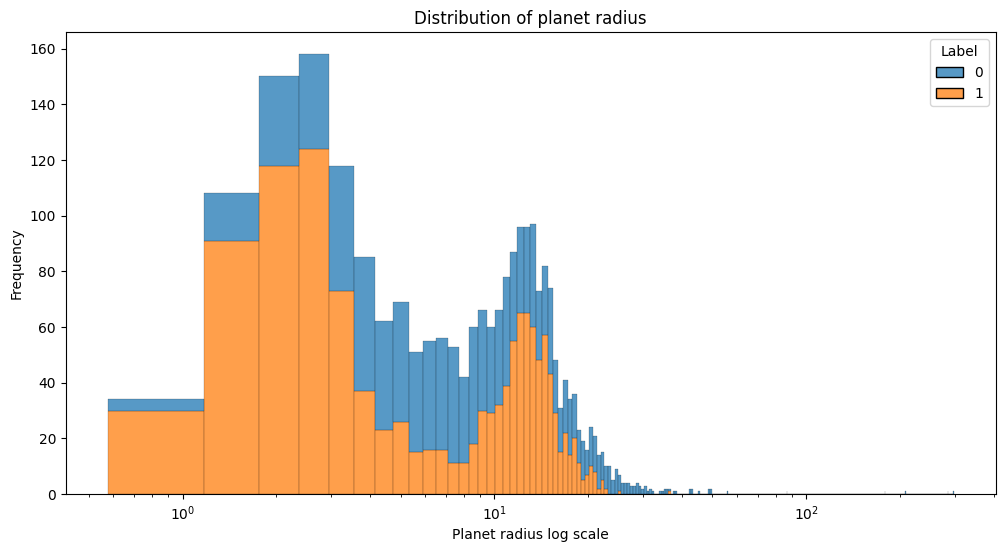

In [63]:
plt.figure(figsize=(12,6))
sns.histplot(data=df, x='Planet_radius', hue='Label', bins=500, multiple='stack')

plt.title("Distribution of planet radius")
plt.xscale('log')
plt.ylabel("Frequency")
plt.xlabel("Planet radius log scale")
plt.show()

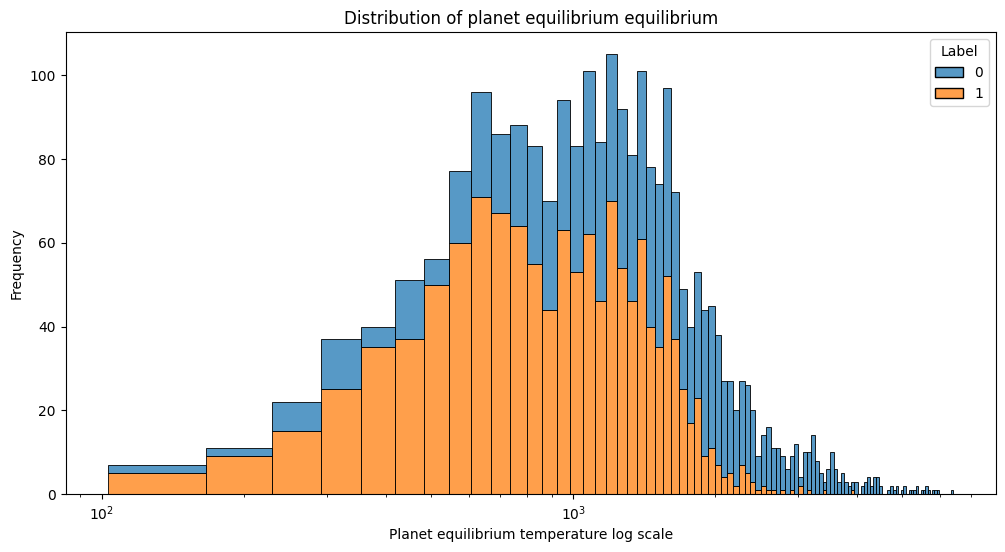

In [64]:
plt.figure(figsize=(12,6))
sns.histplot(data=df, x='Planet_equilibrium_temperature', hue='Label', bins=100, multiple='stack')

plt.title("Distribution of planet equilibrium equilibrium")
plt.xscale('log')
plt.ylabel("Frequency")
plt.xlabel("Planet equilibrium temperature log scale")
plt.show()

The distribution of stellar temperature is something that might lead us to some kind of bias. There is a bump in the distribution towards the lower values. We can't really assume that there are more exoplanets in colder stars because all that is happening is that finding planets in hot, young stars is difficult.

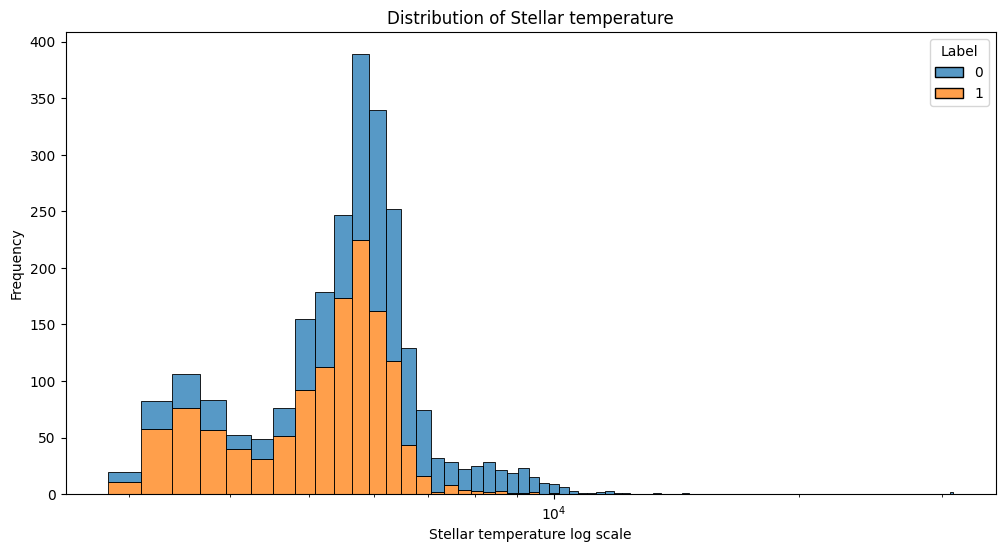

In [65]:
plt.figure(figsize=(12,6))
sns.histplot(data=df, x='Stellar_temperature', hue='Label', bins=100, multiple='stack')

plt.title("Distribution of Stellar temperature")
plt.xscale('log')
plt.ylabel("Frequency")
plt.xlabel("Stellar temperature log scale")
plt.show()

We don't really need the TESS ID for our model; we can drop it.

In [66]:
df = df.drop('Toi', axis=1)

As we can see, we need to log scale the measurements.

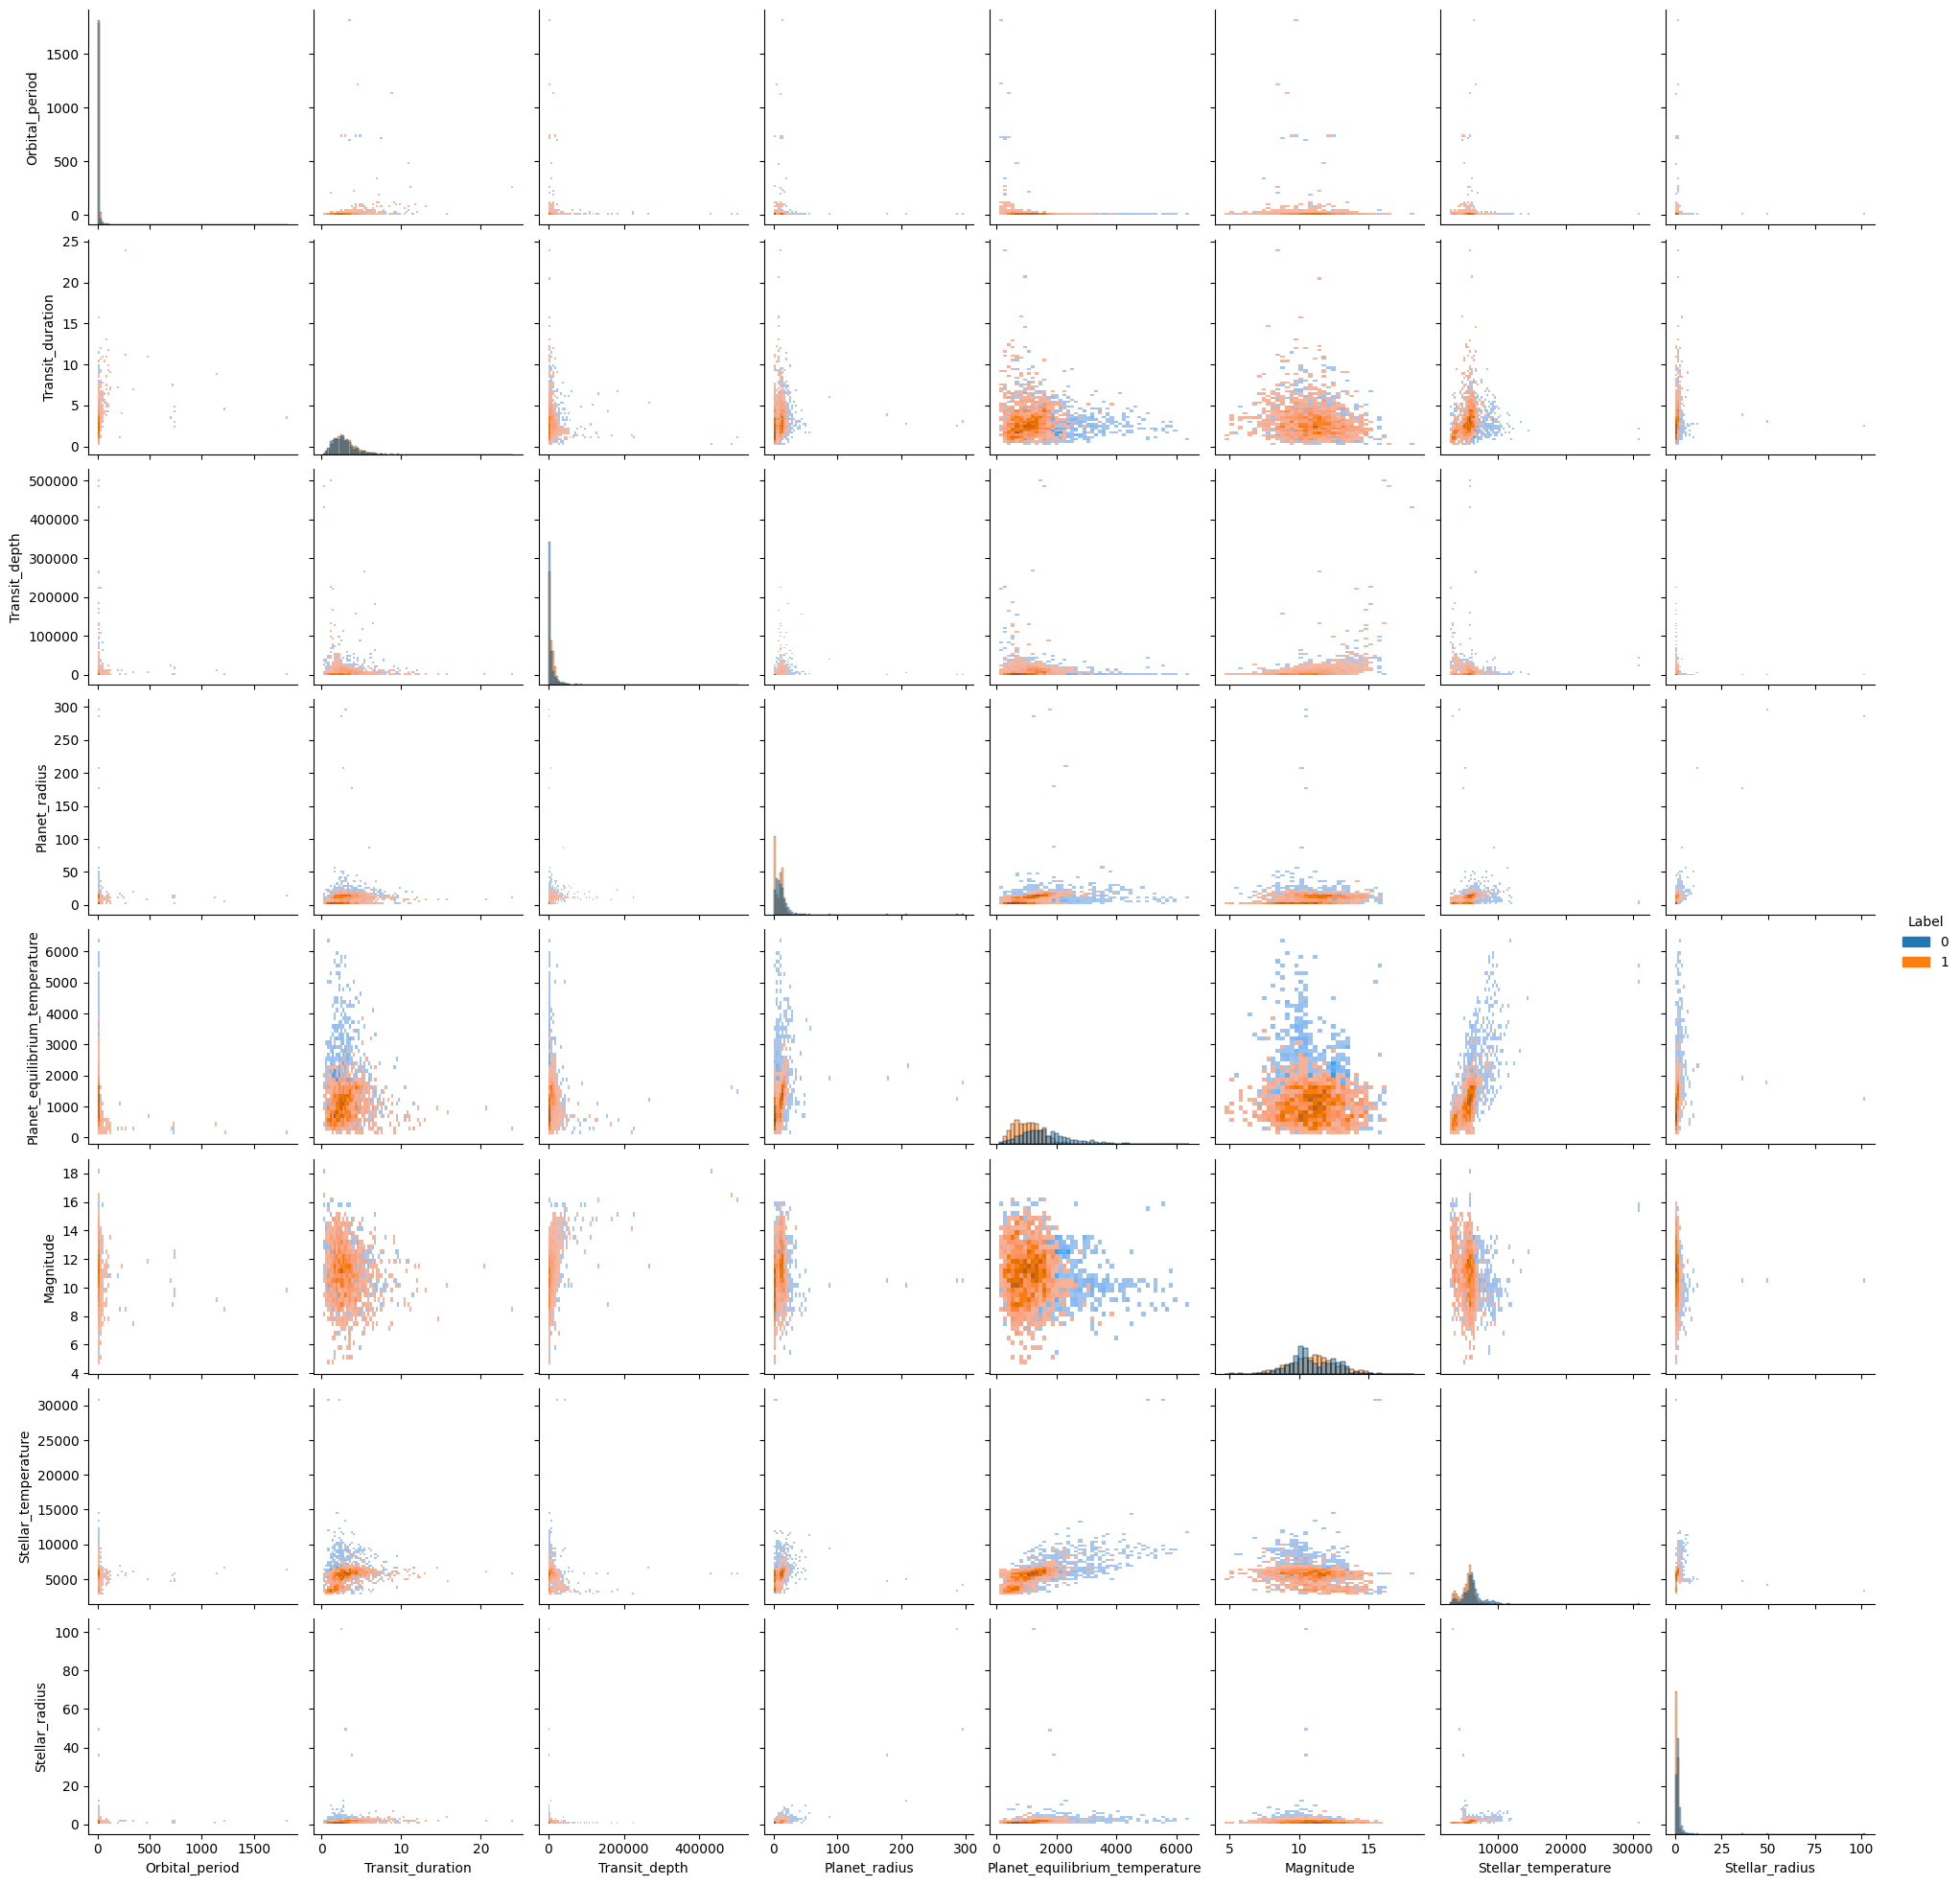

In [67]:
sns.pairplot(data=df, hue='Label', kind='hist')

Even the correlation matrix is not that helpful.

Text(0.5, 1.0, 'Correlation matrix')

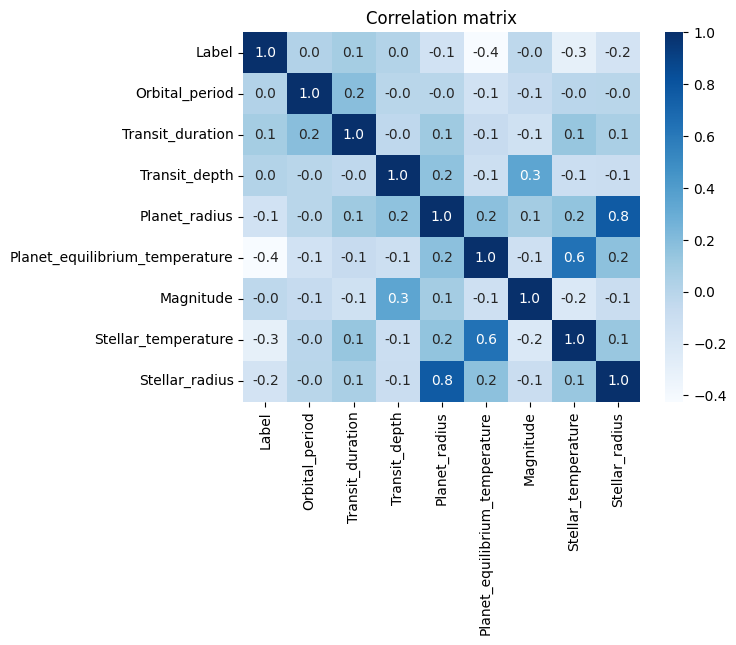

In [68]:
sns.heatmap(df.corr(), annot=True, fmt='.1f', cmap='Blues')
plt.title("Correlation matrix")

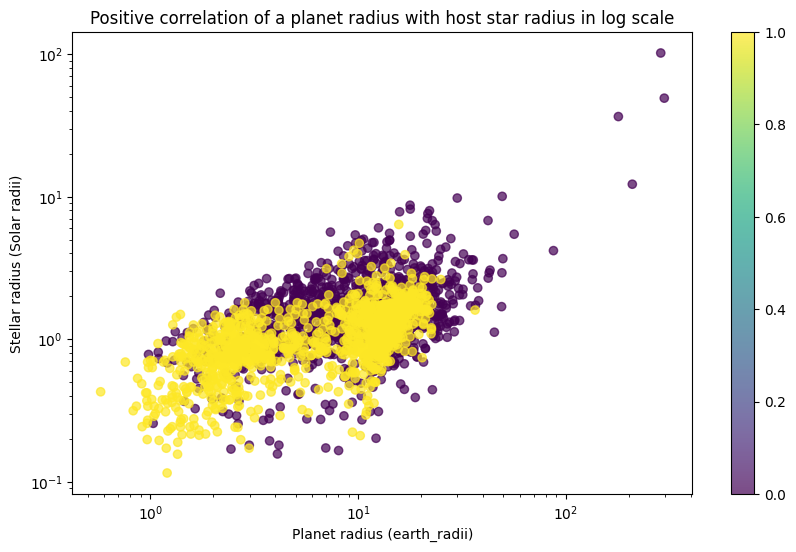

In [69]:
plt.figure(figsize=(10,6))
plt.scatter(x=df['Planet_radius'], y=df['Stellar_radius'], c=df['Label'], alpha=0.7)

plt.title('Positive correlation of a planet radius with host star radius in log scale')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Planet radius (earth_radii)')
plt.ylabel('Stellar radius (Solar radii)')
plt.colorbar()
plt.show()

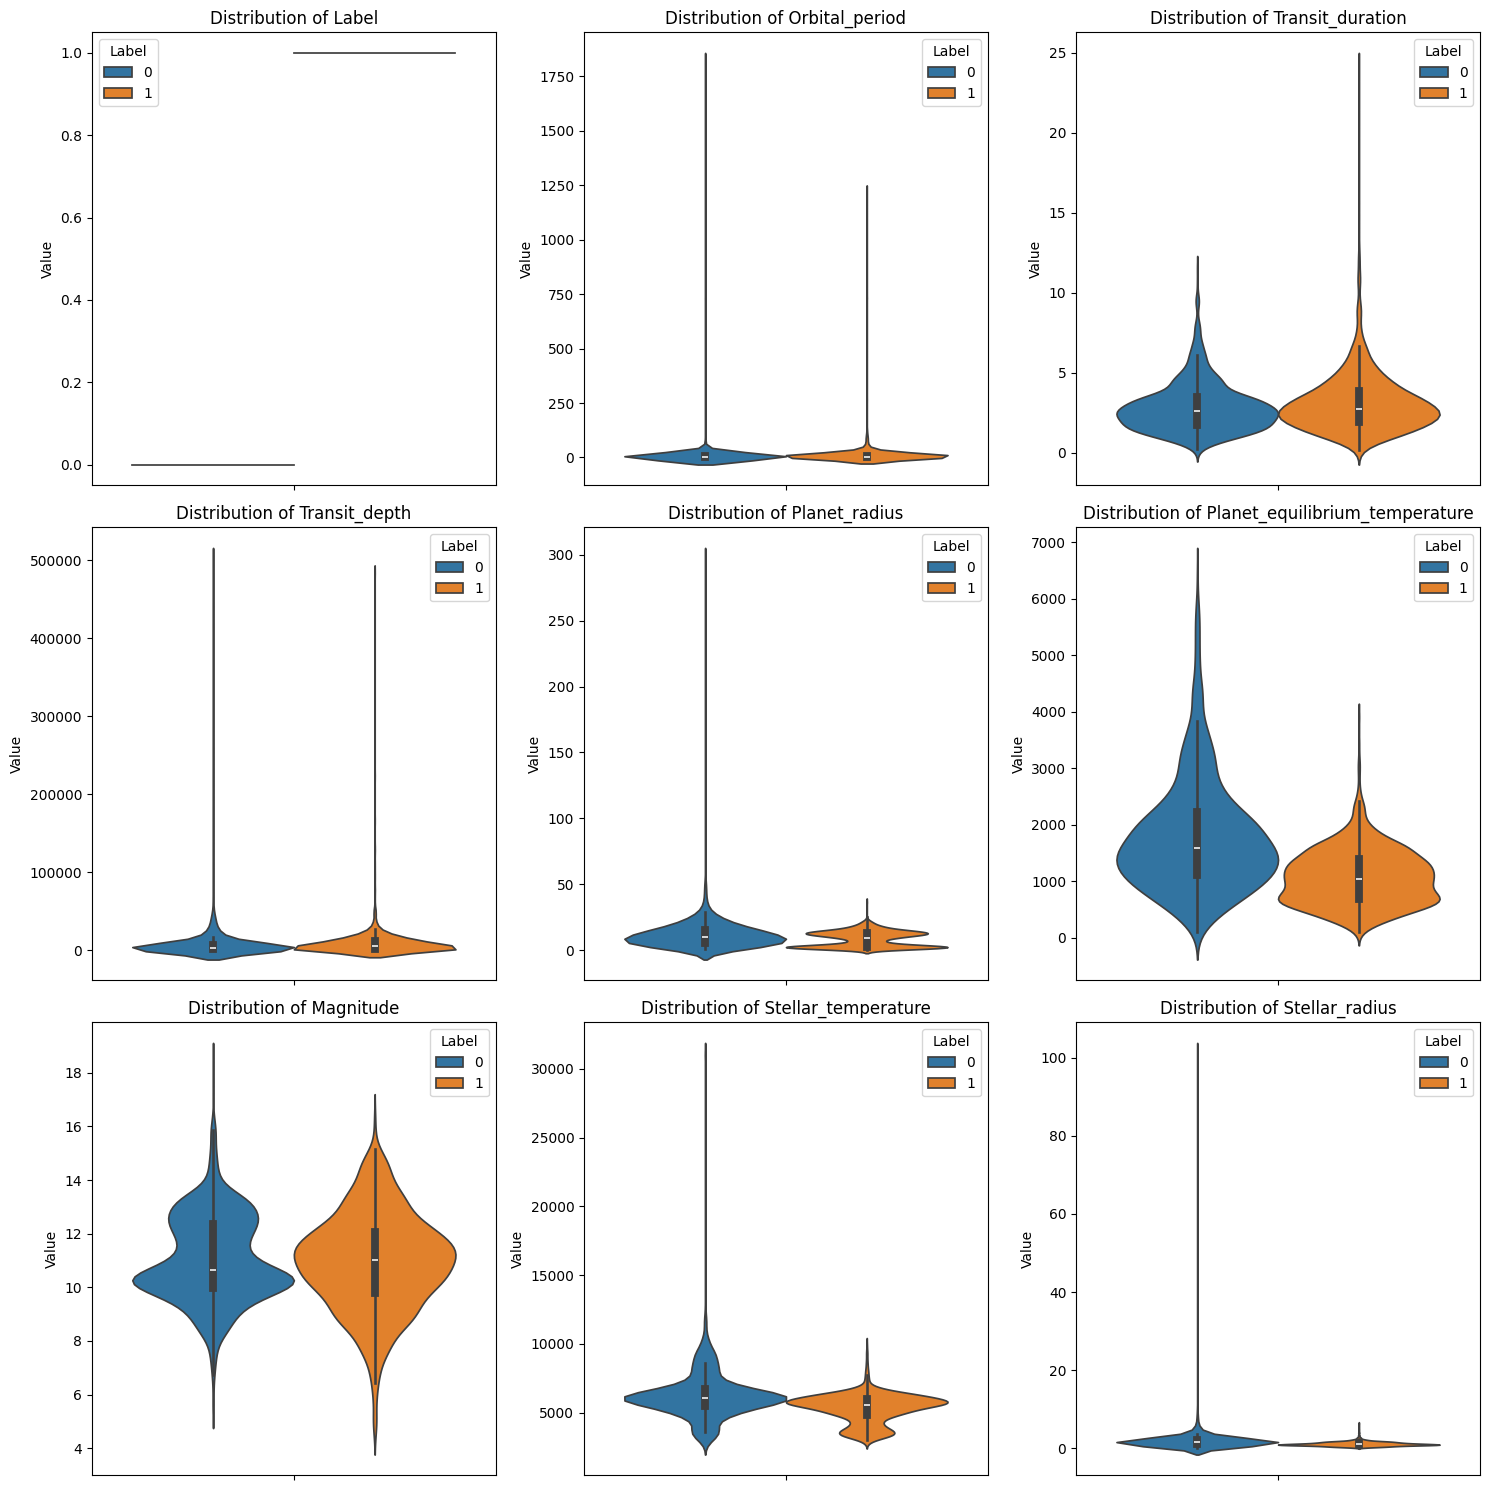

In [70]:
import math
cols_plot = df.columns

n_cols = 3
n_rows = math.ceil(len(cols_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))

axes = axes.flatten()

for i, col in enumerate(cols_plot):
    sns.violinplot(data=df, y=col, ax=axes[i], hue='Label')
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_ylabel("Value")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

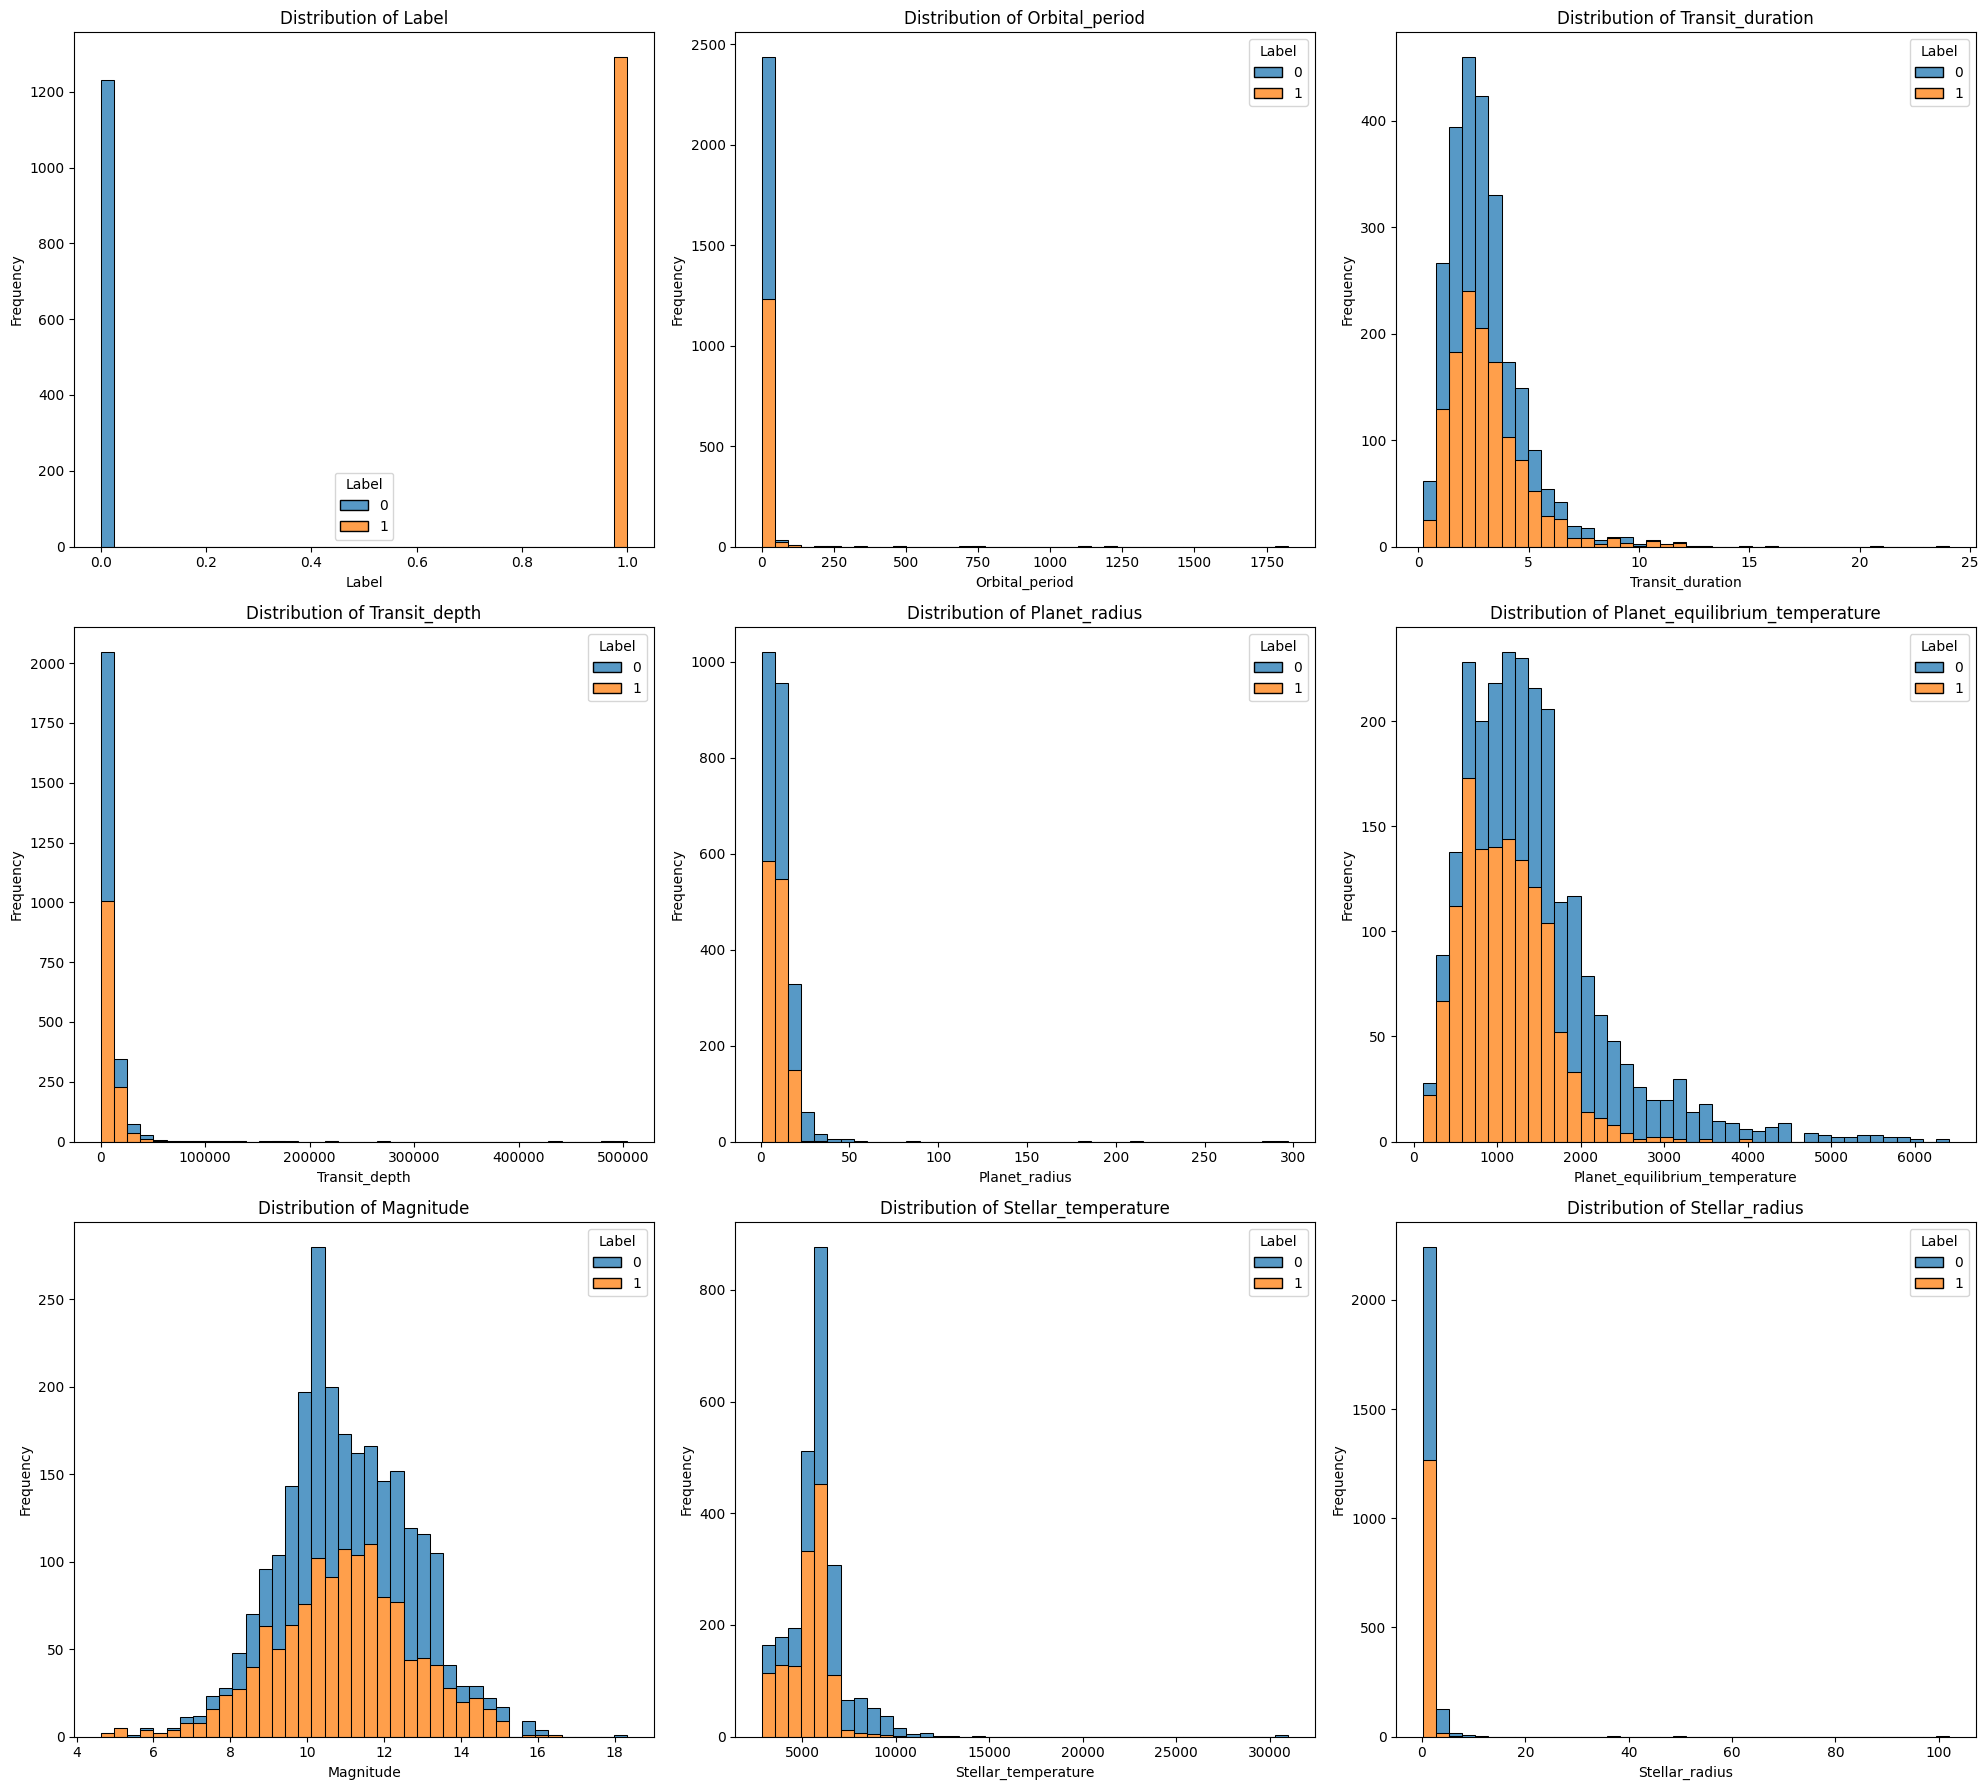

In [71]:
cols_plot = df.columns

n_cols = 3
n_rows = math.ceil(len(cols_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 6*n_rows))

axes = axes.flatten()

for i, col in enumerate(cols_plot):
    sns.histplot(data=df, x=col, ax=axes[i], bins=40, hue='Label', multiple='stack')
    axes[i].set_xscale('linear')
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_ylabel("Frequency")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Feature engineering

We can add some pretty interesting features, like the ratio of the star radius and planet radius (this improves the models somewhat). Then we can add the ratio of a transit duration to its orbital period.

Then we scale the features.

In [111]:
#add the new features

df['Planet_to_star_radius_ratio'] = df['Stellar_radius'] / df['Planet_radius']
df['Duration_per_ratio'] = df['Transit_duration'] / df['Orbital_period']

In [73]:
df.columns

Index(['Label', 'Orbital_period', 'Transit_duration', 'Transit_depth',
       'Planet_radius', 'Planet_equilibrium_temperature', 'Magnitude',
       'Stellar_temperature', 'Stellar_radius', 'Planet_to_star_radius_ratio',
       'Duration_per_ratio'],
      dtype='object')

In [74]:
log_features = ["Orbital_period", "Transit_duration", "Transit_depth", "Planet_radius",
 "Planet_equilibrium_temperature", "Stellar_temperature", "Stellar_radius"]

for feature in df[log_features]:
    df[feature] = np.log(df[feature])

This is much much better, the reletionships/distributions are now clear.

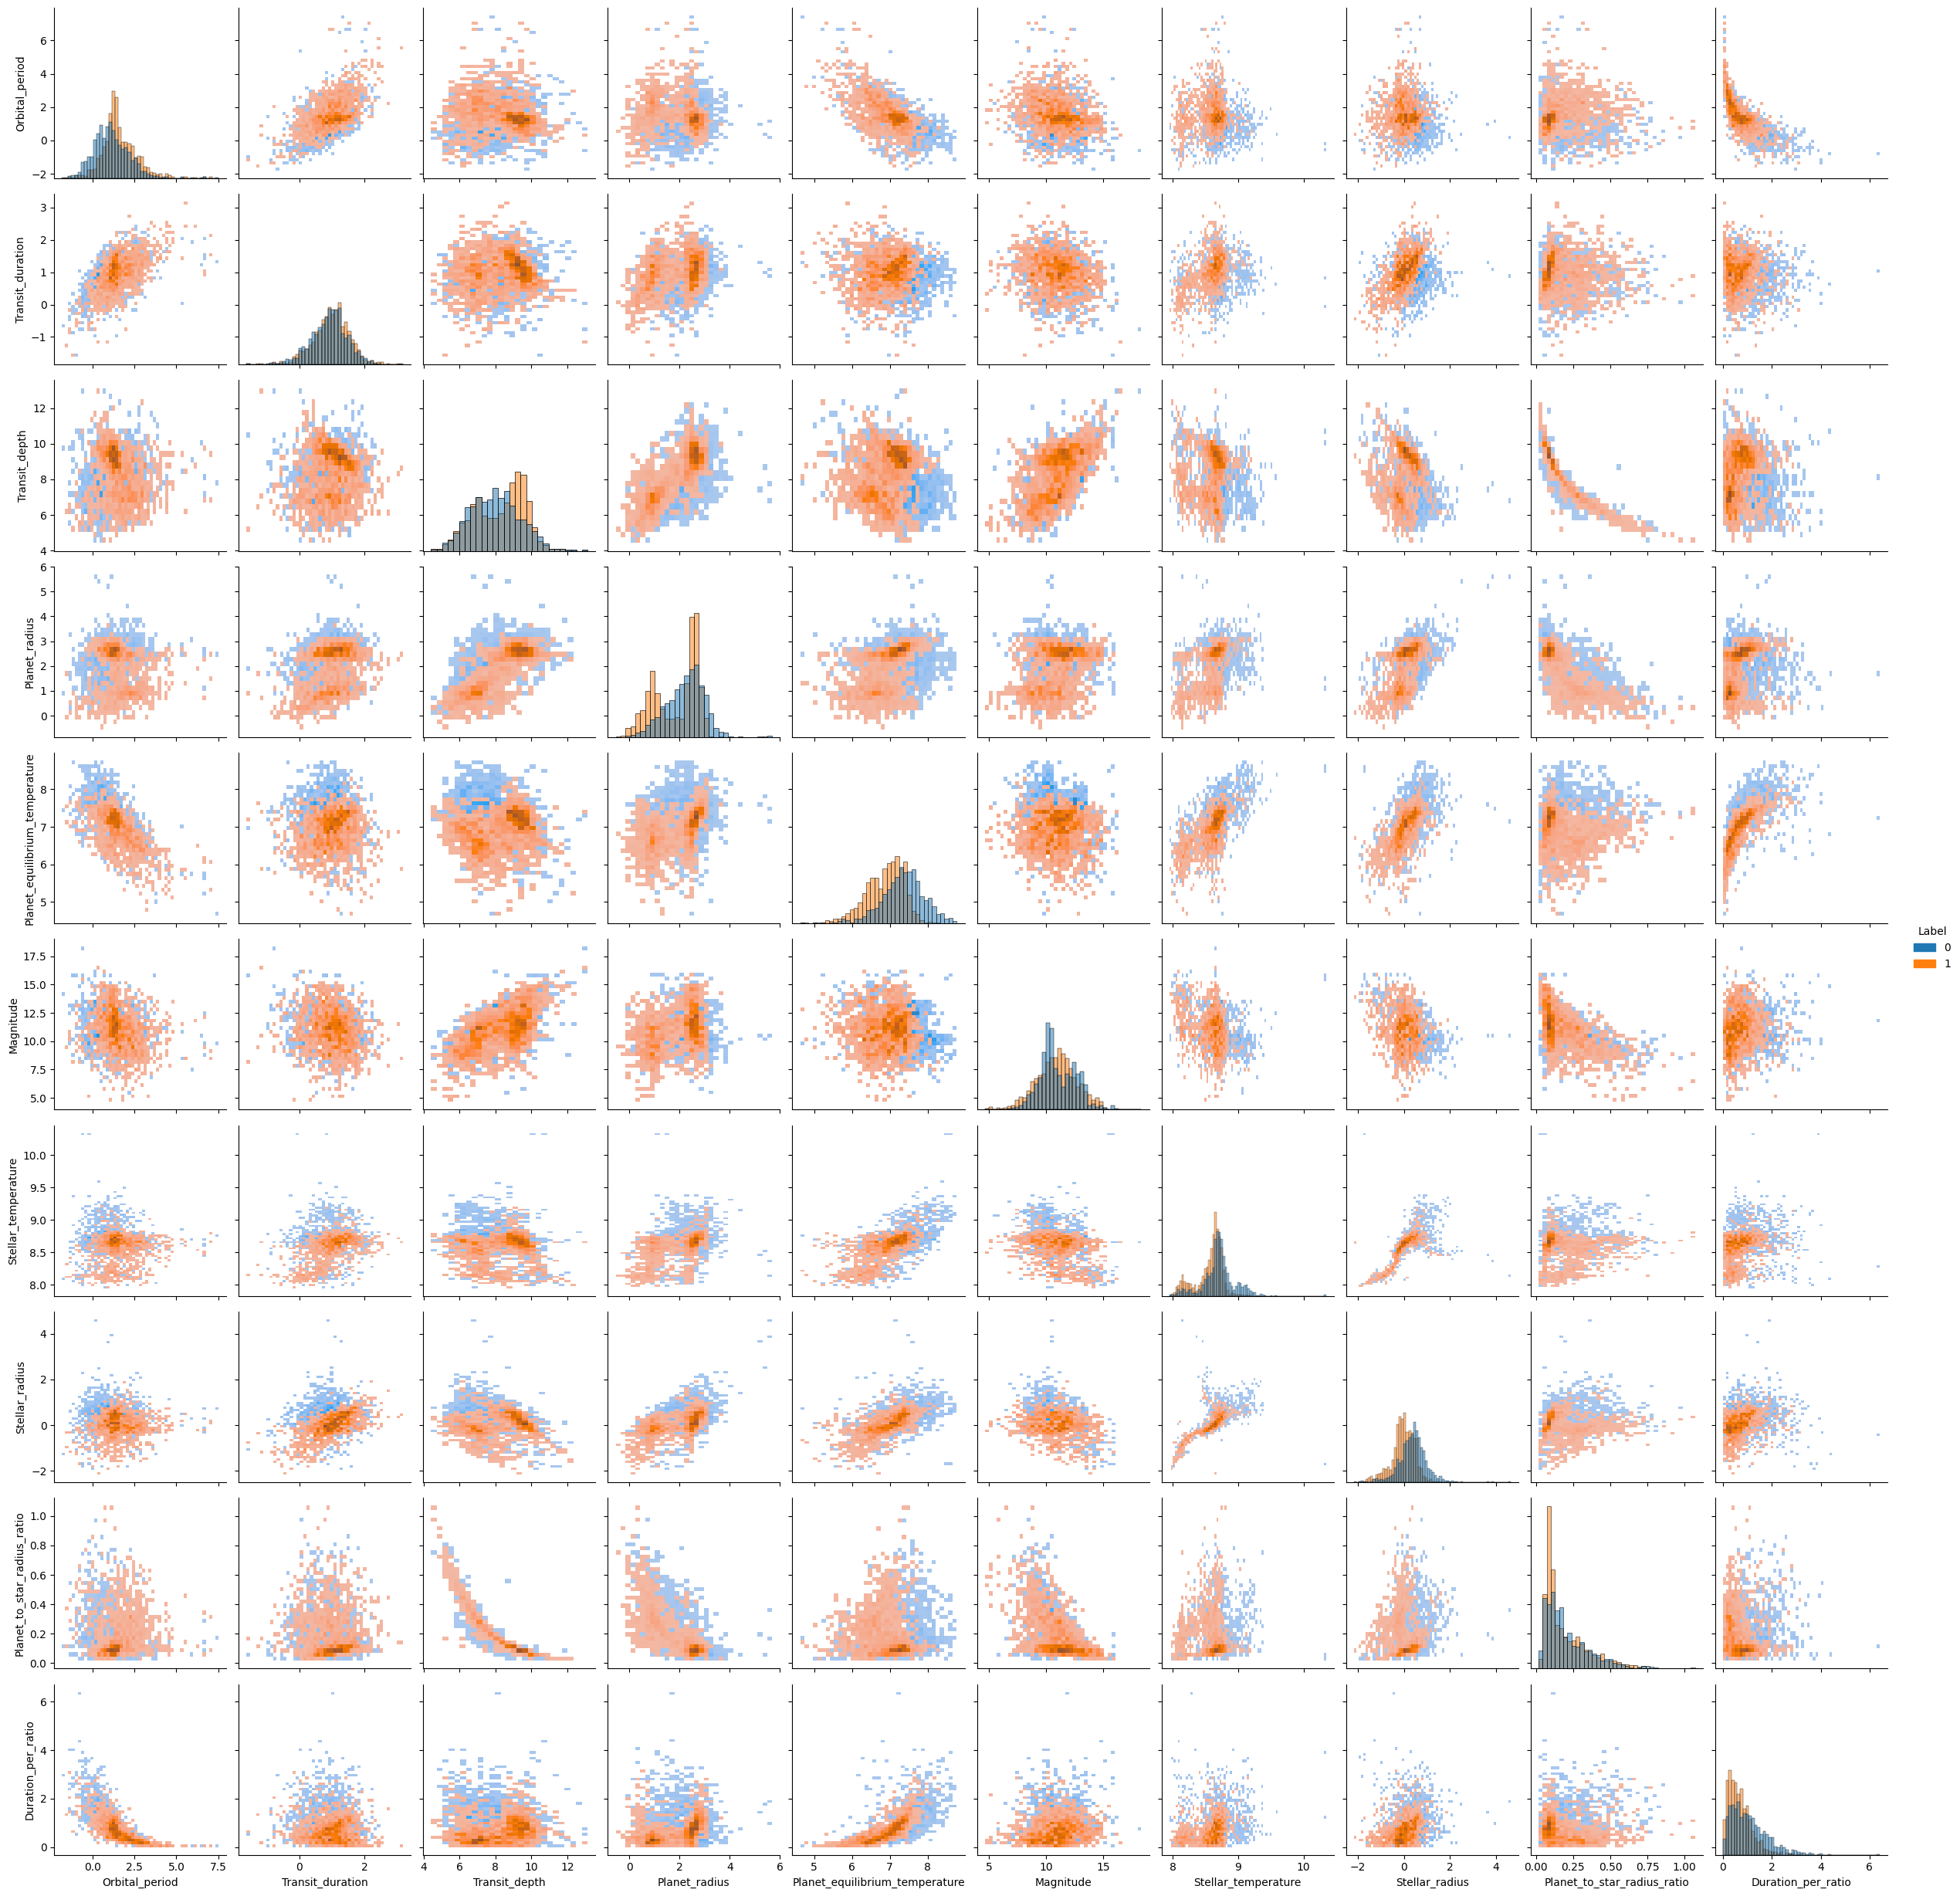

In [75]:
sns.pairplot(data=df, hue='Label', kind='hist') #lets visualize again

Using a plotly 3d scatter plot, we can identify relationship and check if the two classes are separable.

In [76]:
fig = px.scatter_3d(
    df,
    x = 'Planet_radius', 
    y = 'Orbital_period', 
    z = 'Planet_equilibrium_temperature',
    color='Label', 
)

fig.update_traces(marker = dict(size=4))

fig.show()

In [77]:
fig = px.scatter_3d(
    df,
    x = 'Transit_depth', 
    y = 'Orbital_period', 
    z = 'Transit_duration',
    color='Label', 
)

fig.update_traces(marker = dict(size=4))

fig.show()

In [78]:
fig = px.scatter_3d(
    df,
    x = 'Planet_radius', 
    y = 'Transit_depth', 
    z = 'Transit_duration',
    color='Label', 
)

fig.update_traces(marker = dict(size=4))

fig.show()

#the result is a very nice scatter plot, where the two classes are already almost separable

In [79]:
fig = px.scatter_3d(
    df,
    x = 'Planet_radius', 
    y = 'Orbital_period', 
    z = 'Stellar_radius',
    color='Label', 
)

fig.update_traces(marker = dict(size=4))

fig.show()

In [80]:
fig = px.scatter_3d(
    df,
    x = 'Planet_to_star_radius_ratio', 
    y = 'Duration_per_ratio', 
    z = 'Stellar_temperature',
    color='Label', 
)

fig.update_traces(marker = dict(size=4))

fig.show()

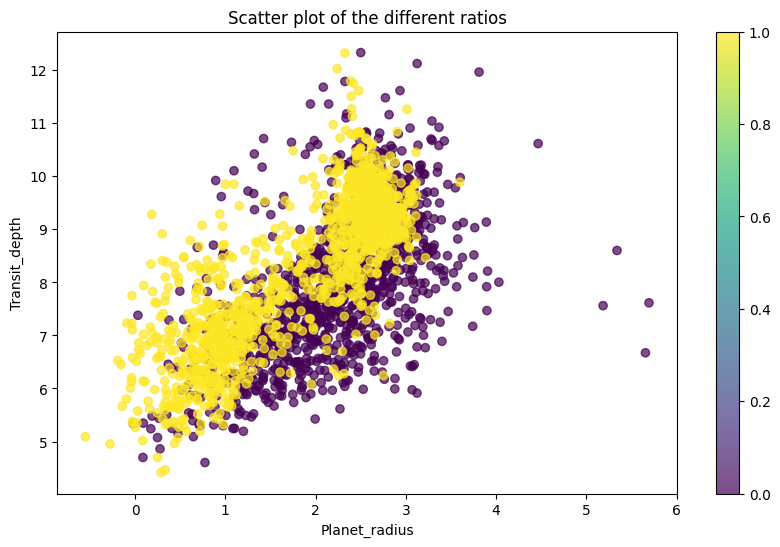

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(df['Planet_radius'], df['Transit_depth'], c=df['Label'], alpha=0.7)

#this a pretty obvius relationship
plt.xlabel('Planet_radius')
plt.ylabel('Transit_depth')
plt.title('Scatter plot of the different ratios')
plt.colorbar()
plt.show()

After scaling, the relationship between features is more evident: Planet_equilibrum_temperature is related to lots of features and might be a proxy variable, so we'd better keep an eye on that.  

Text(0.5, 1.0, 'Correlation matrix, log_scaled_features')

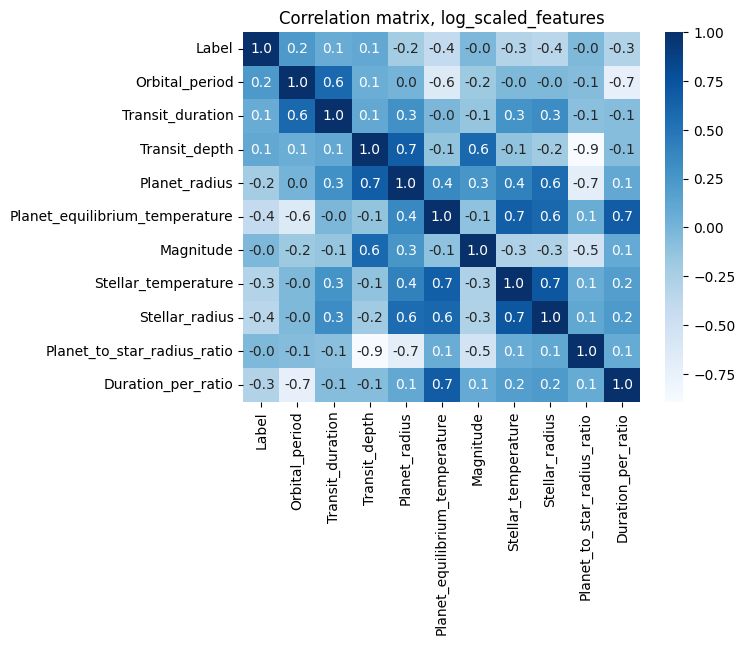

In [82]:
sns.heatmap(df.corr(), annot=True, fmt='.1f', cmap='Blues')
plt.title("Correlation matrix, log_scaled_features")

The new log-scaled features are much better now. With the violin plot, we can see that there are some evident differences between false positives and confirmed planets.

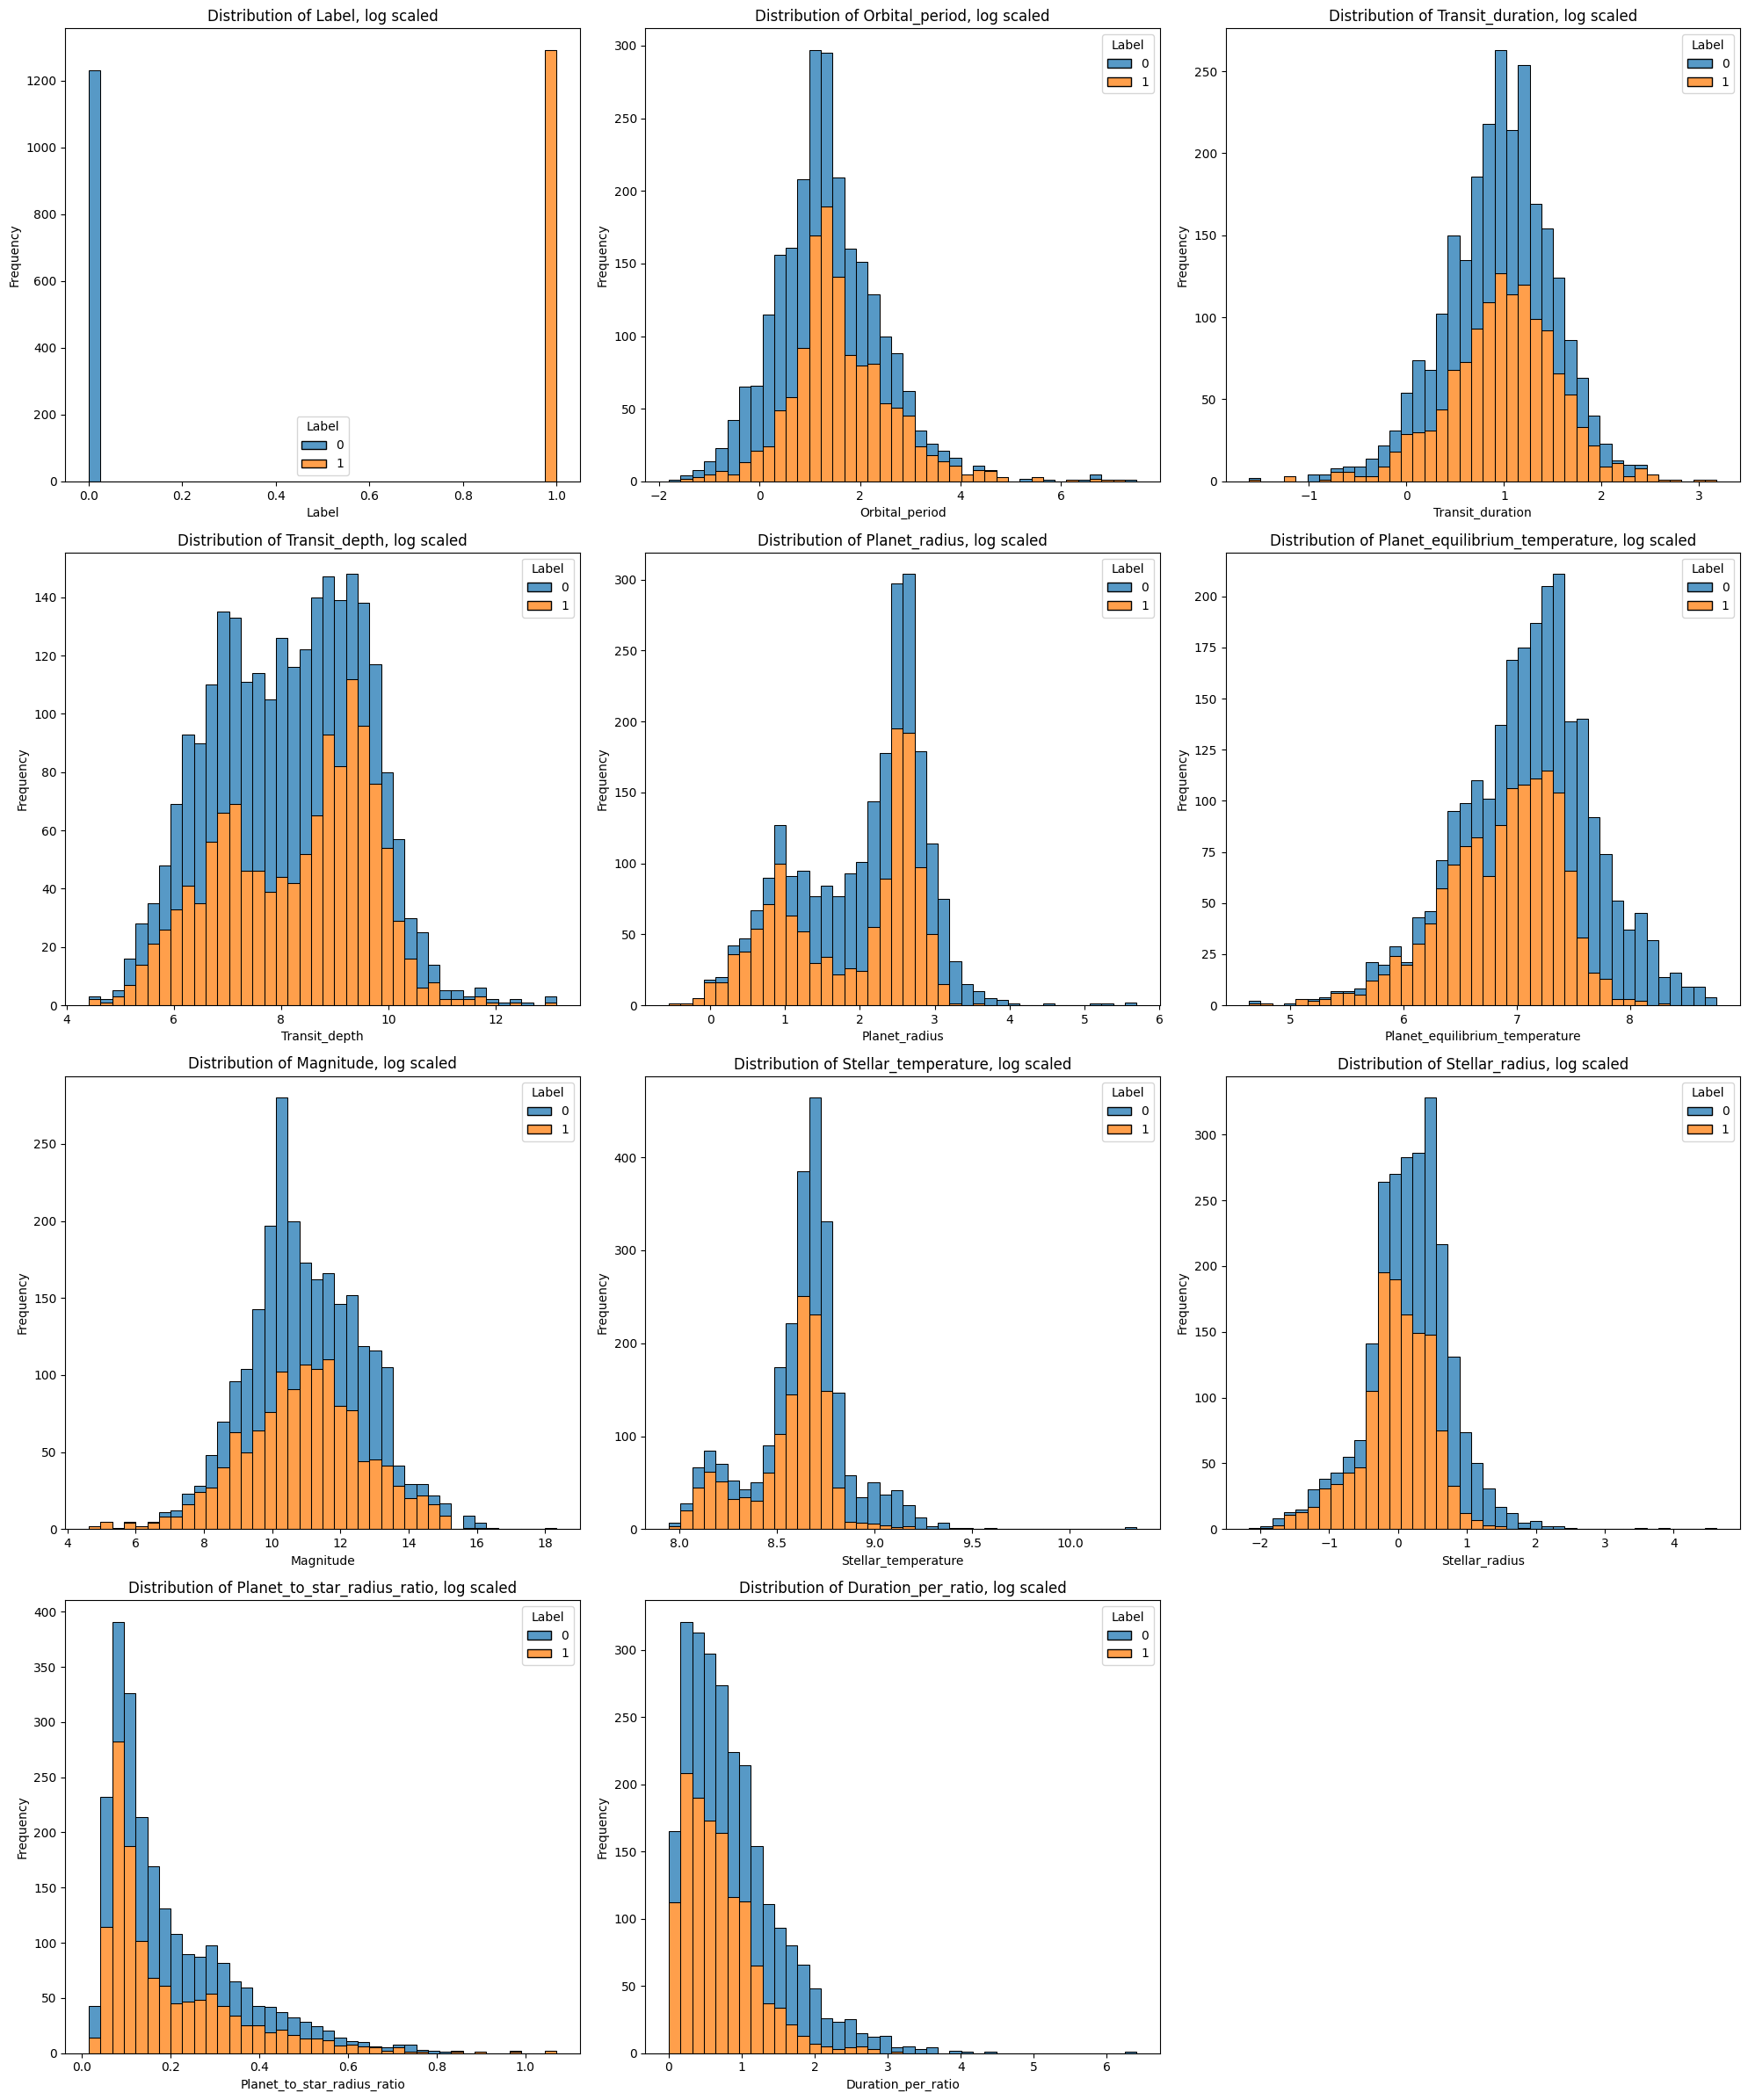

In [ ]:
#We can visualize the distributions to see how the characteristics of the two classes differ.

cols_plot = df.columns

n_cols = 3
n_rows = math.ceil(len(cols_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 6*n_rows))

axes = axes.flatten()

for i, col in enumerate(cols_plot):
    sns.histplot(data=df, x=col, ax=axes[i], bins=40, hue='Label', multiple='stack')
    axes[i].set_xscale('linear')
    axes[i].set_title(f"Distribution of {col}, log scaled")
    axes[i].set_ylabel("Frequency")

for j in range(i+1, len(axes)): #check the correct number of plots
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

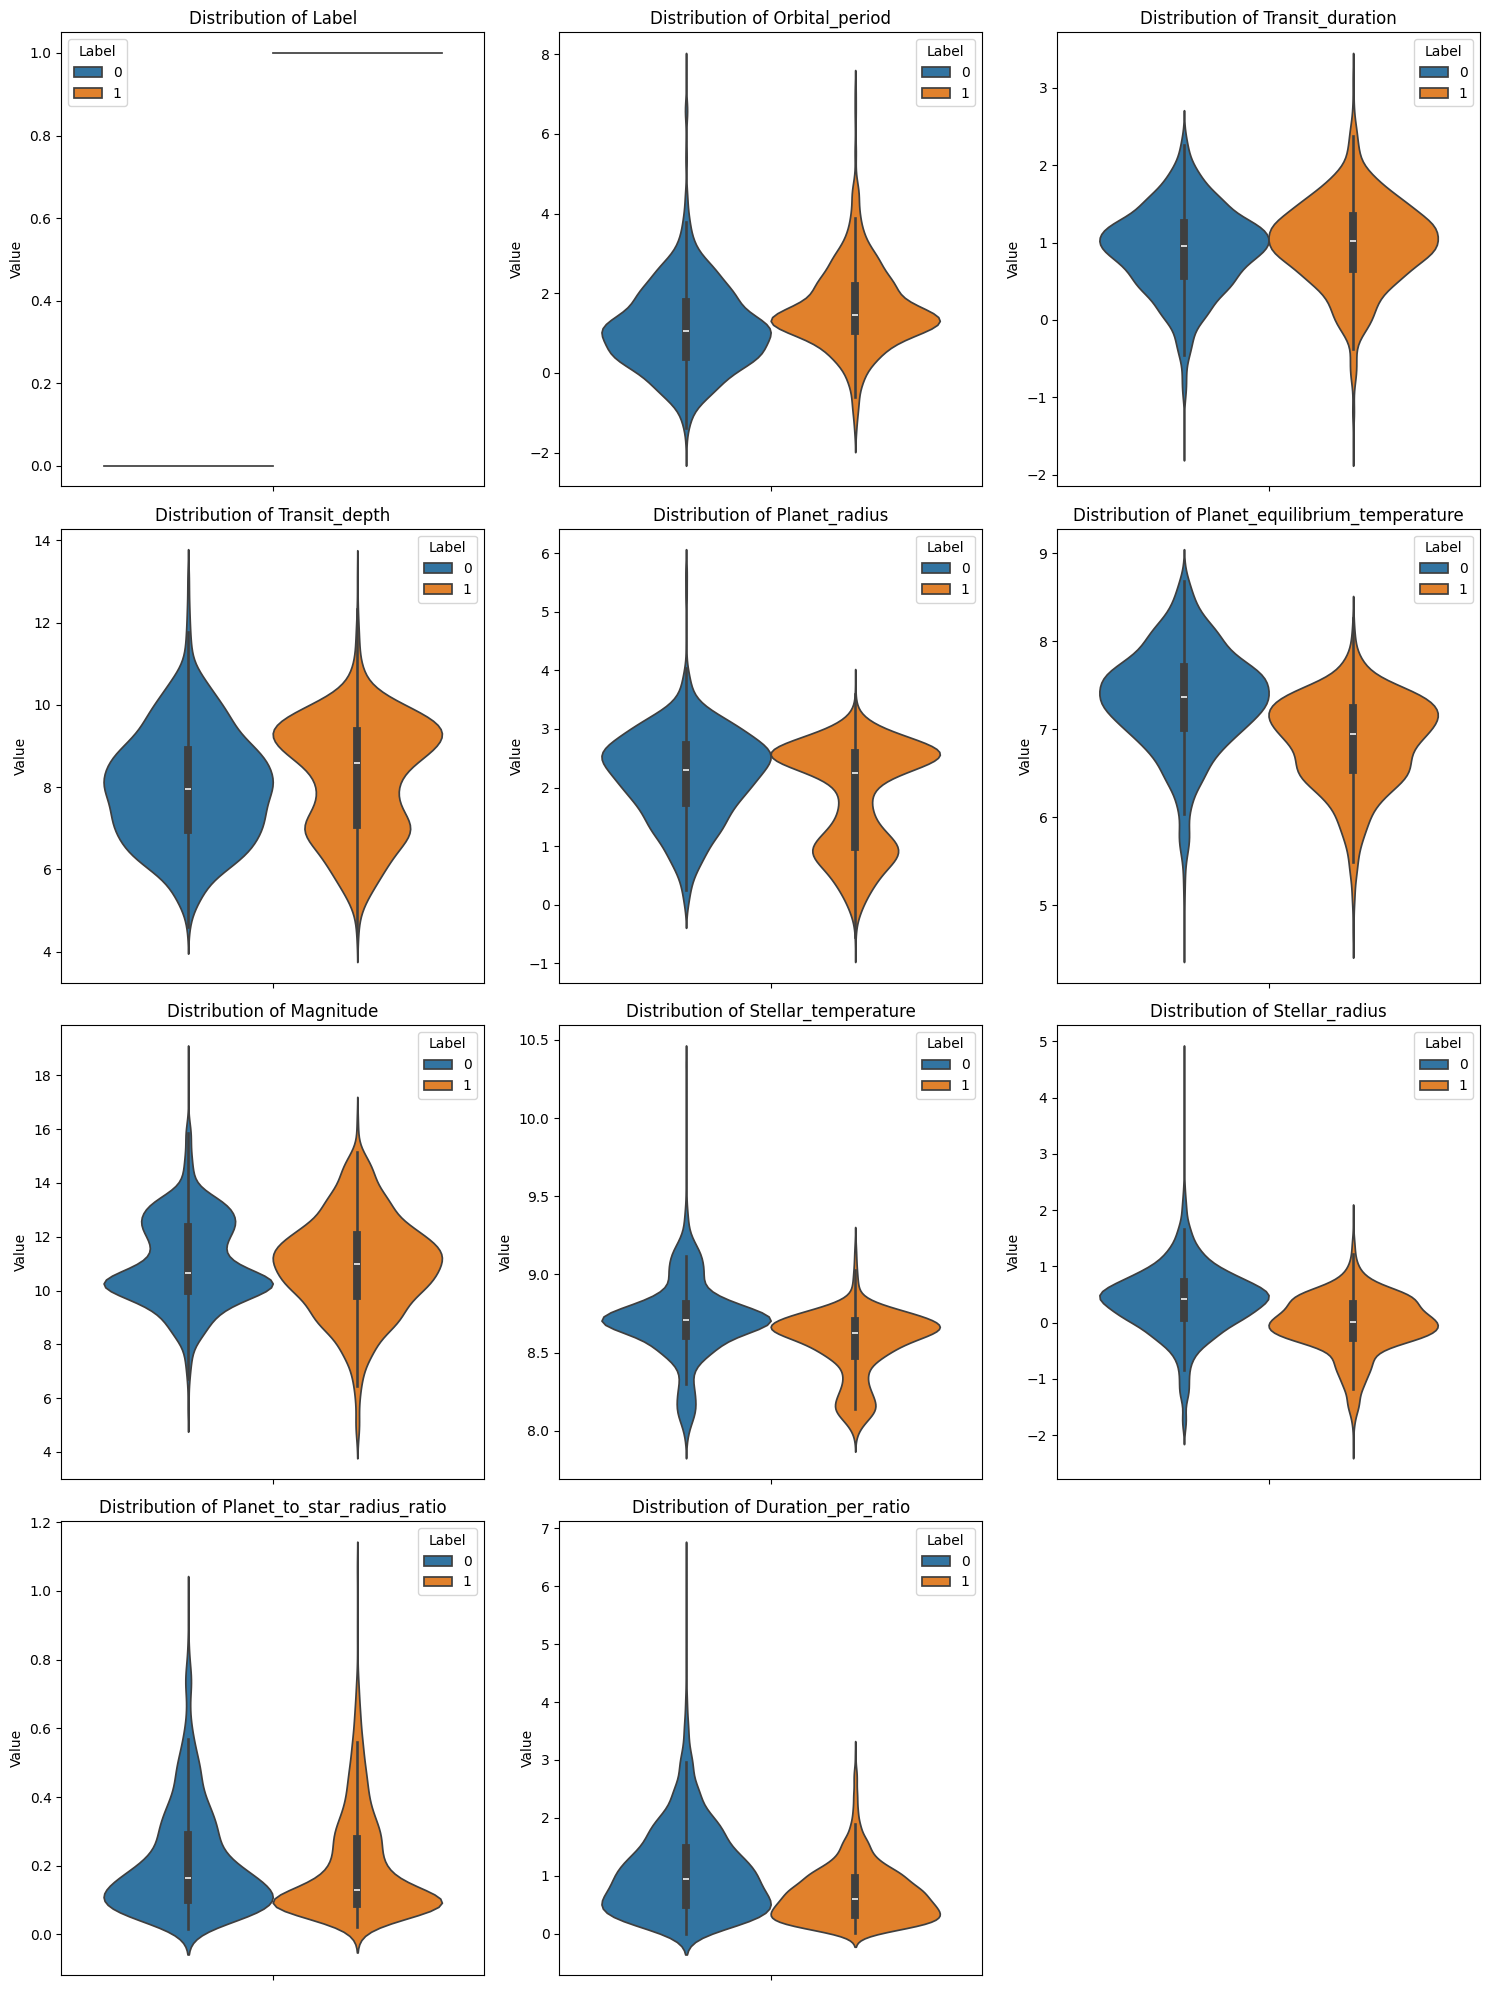

In [ ]:
#We can do the same with violin plots

cols_plot = df.columns

n_cols = 3
n_rows = math.ceil(len(cols_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))

axes = axes.flatten()

for i, col in enumerate(cols_plot):
    sns.violinplot(data=df, y=col, ax=axes[i], hue='Label')
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_ylabel("Value")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

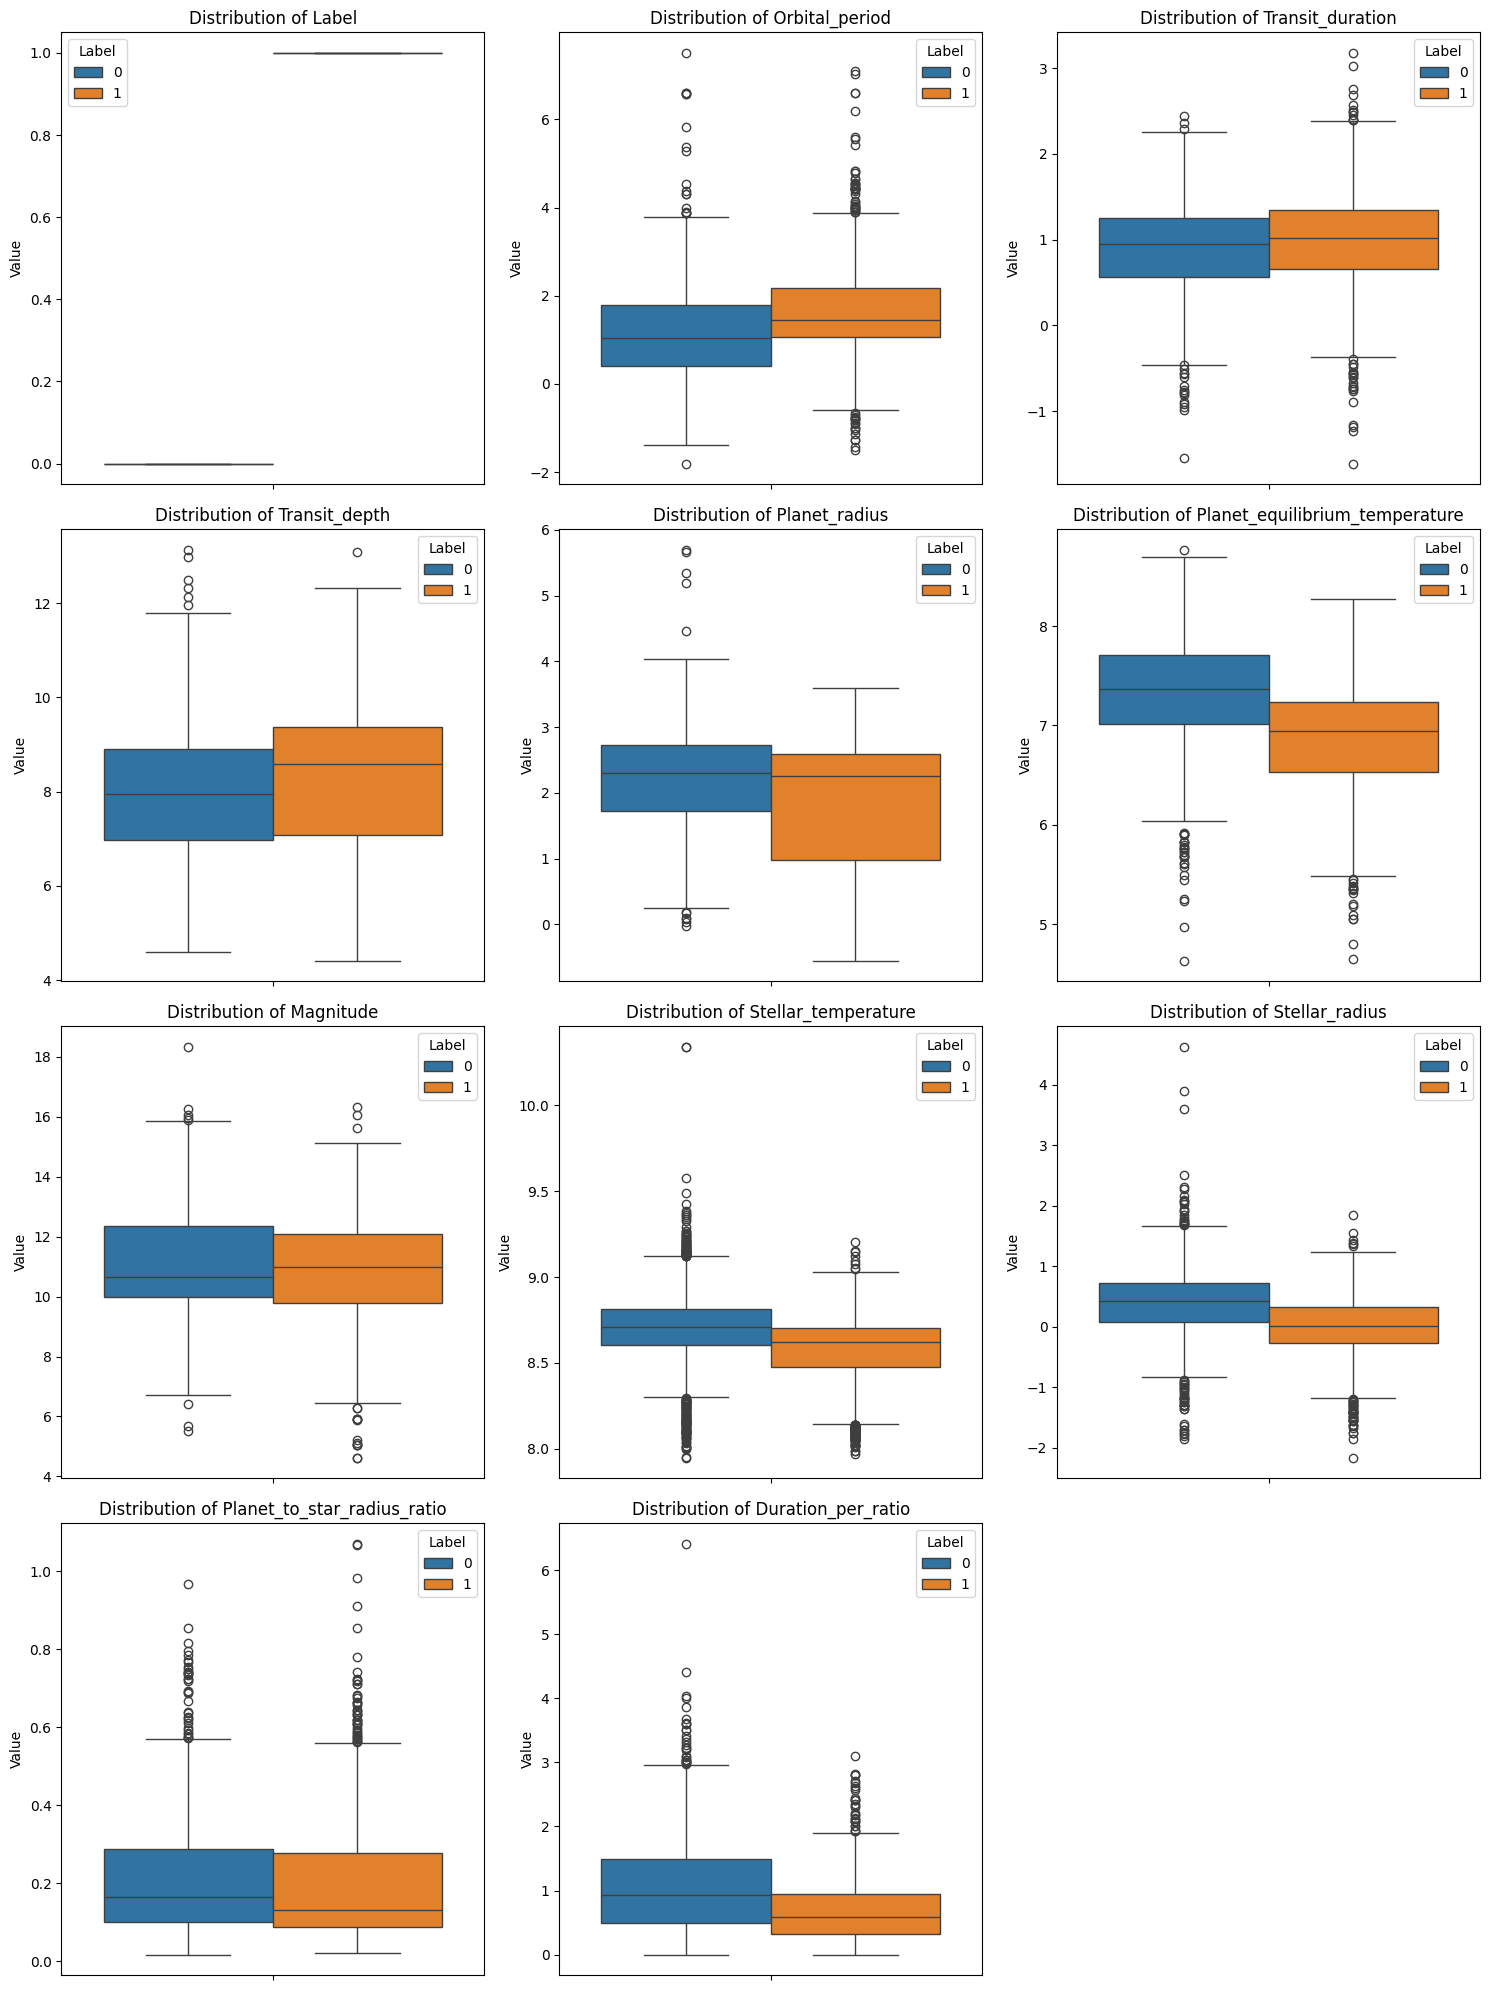

In [ ]:
#And with boxplots too

cols_plot = df.columns

n_cols = 3
n_rows = math.ceil(len(cols_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))

axes = axes.flatten()

for i, col in enumerate(cols_plot):
    sns.boxplot(data=df, y=col, ax=axes[i], hue='Label')
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_ylabel("Value")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

An advanced tool for visualizing non-linear relationships is 'Andrews Curves', which are made from a sequence of goniometric equations. We can see that the two classes are mostly similar, apart from some outliers

<Axes: title={'center': 'Andrews Curves'}>

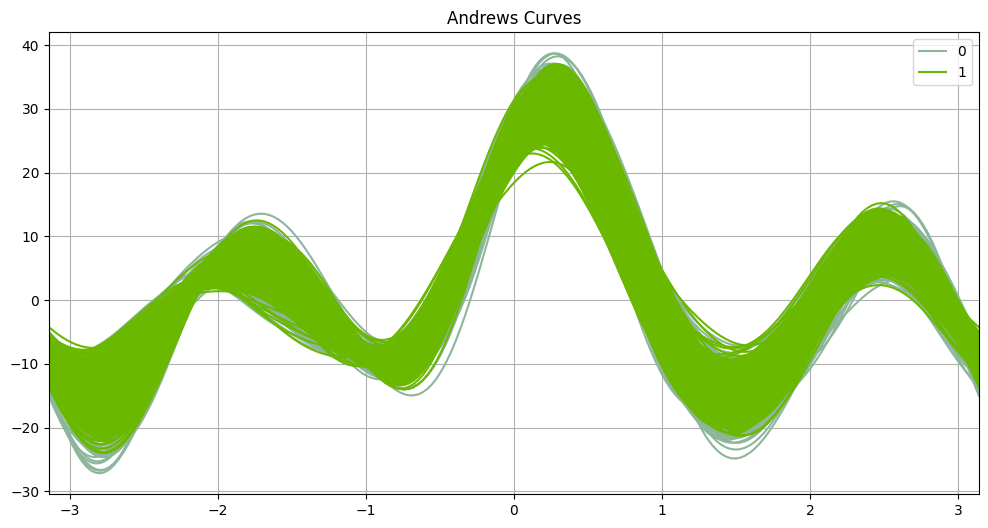

In [86]:
plt.figure(figsize=(12,6))
plt.title("Andrews Curves")
pd.plotting.andrews_curves(df, "Label")

## The creation of the different Models. 

In [ ]:
#Import of all the modules that we need to create our models

from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier, StackingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import KNeighborsClassifier

In [88]:
X = df.drop(columns='Label', axis=1)
y = df['Label']

In [ ]:
#split the dataset into train-test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [90]:
hgclf = HistGradientBoostingClassifier(random_state=42, max_iter=1000)
rf = RandomForestClassifier(random_state=42)
svc = SVC(random_state=42, probability=True)
lr = LogisticRegression(random_state=42, max_iter=10000)
knn = KNeighborsClassifier()


In [ ]:
#We can create the different grids of parameters for future hyperparameter tuning.
param_grid_hgclf = {
    'learning_rate': [1, 0.1, 0.01, 0.001],
    'max_leaf_nodes': [10, 20, 30, 40],
    'min_samples_leaf': [15, 20, 30 , 40],
    'l2_regularization': [1, 0, 0.1, 0.01]
}

param_grid_lr = {
    'logisticregression__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'logisticregression__l1_ratio': [0]
}

param_grid_rf = {
    'n_estimators': [50, 100, 200, 400],
    'criterion': ['gini', 'entropy'],
    'max_depth': [4, 5, 6, 7, 8],
    'max_features': [None, 'sqrt', 'log2'],
}

param_grid_knn = {
    'kneighborsclassifier__n_neighbors': [3, 4, 5, 8, 12],
    'kneighborsclassifier__weights': ['uniform', 'distance'],
    'kneighborsclassifier__metric': ['euclidean', 'manhattan', 'minkowski']
}

param_grid_svc = {
    'svc__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'svc__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'svc__gamma': ['scale', 'auto']
}


In [ ]:
#First we try without imputing the values with histgradientboost

KCV_hg = RandomizedSearchCV(hgclf, param_grid_hgclf, cv = StratifiedKFold(n_splits=5), scoring='average_precision', error_score='raise')

In [93]:
KCV_hg.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",HistGradientB...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'l2_regularization': [1, 0, ...], 'learning_rate': [1, 0.1, ...], 'max_leaf_nodes': [10, 20, ...], 'min_samples_leaf': [15, 20, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that ca

In [94]:
print(f"HGB:{classification_report(y_test, KCV_hg.predict(X_test))}")

#HGB does a great job with the dataset scoring an accuracy of 86%

HGB:              precision    recall  f1-score   support

           0       0.90      0.81      0.85       246
           1       0.83      0.92      0.87       259

    accuracy                           0.86       505
   macro avg       0.87      0.86      0.86       505
weighted avg       0.87      0.86      0.86       505



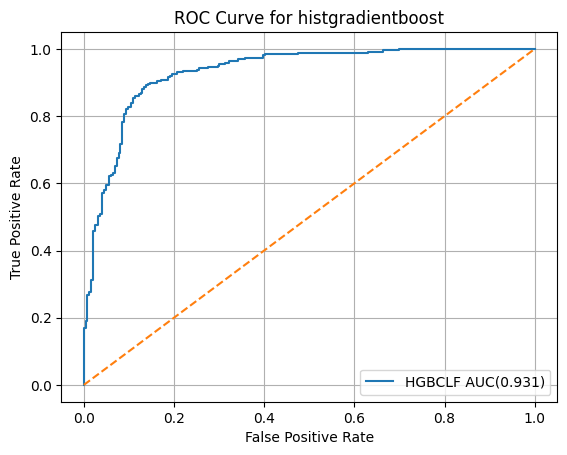

In [95]:
#One way we evaluate a classifier is through a ROC curve, which tell us how good is our model

y_score = KCV_hg.predict_proba(X_test)[:, 1]

fpr_hg, tpr_hg, _ = roc_curve(y_test, y_score)
roc_auc_hg = roc_auc_score(y_test, y_score)

plt.plot(fpr_hg, tpr_hg, label=f'HGBCLF AUC({roc_auc_hg:.3f})')

plt.plot([0, 1], [0, 1], "--") #dumb classifier
plt.legend()
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for HGB")
plt.grid(True)
plt.show()

In [ ]:
#Now let's try imputing the values with a simple imputer and look at the result: 

preprocess = SimpleImputer(strategy='most_frequent')

In [97]:
X_train_processed = preprocess.fit_transform(X_train)

In [98]:
X_test_processed = preprocess.transform(X_test)

In [ ]:
#Convert it back into a dataframe
X_train_processed = pd.DataFrame(X_train_processed, columns=X_train.columns)
X_test_processed = pd.DataFrame(X_test_processed, columns=X_test.columns)

In [ ]:
#By creating a pipeline with robust scaler we ensure better model performance. I decided to use a robust scaler since in the dataset there are many outliers

svc_pipe = make_pipeline(RobustScaler(), svc)
lr_pipe = make_pipeline(RobustScaler(), lr)
knn_pipe = make_pipeline(RobustScaler(), knn)

In [ ]:
#Add cross validation for the randomized grid search to find the best hyperparameters. 

KCV_rf = RandomizedSearchCV(rf, param_grid_rf, cv = StratifiedKFold(n_splits=5), scoring='average_precision', error_score='raise', n_iter=30)
KCV_lr = RandomizedSearchCV(lr_pipe, param_grid_lr, cv = StratifiedKFold(n_splits=5), scoring='average_precision', error_score='raise', n_iter=30)
KCV_svc = RandomizedSearchCV(svc_pipe, param_grid_svc, cv = StratifiedKFold(n_splits=5), scoring='average_precision', error_score='raise', n_iter=30)
KCV_knn = RandomizedSearchCV(knn_pipe, param_grid_knn, cv = StratifiedKFold(n_splits=5), scoring='average_precision', error_score='raise', n_iter=30)


c:\Users\tomma\ml_env\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning:

The total space of parameters 7 is smaller than n_iter=30. Running 7 iterations. For exhaustive searches, use GridSearchCV.



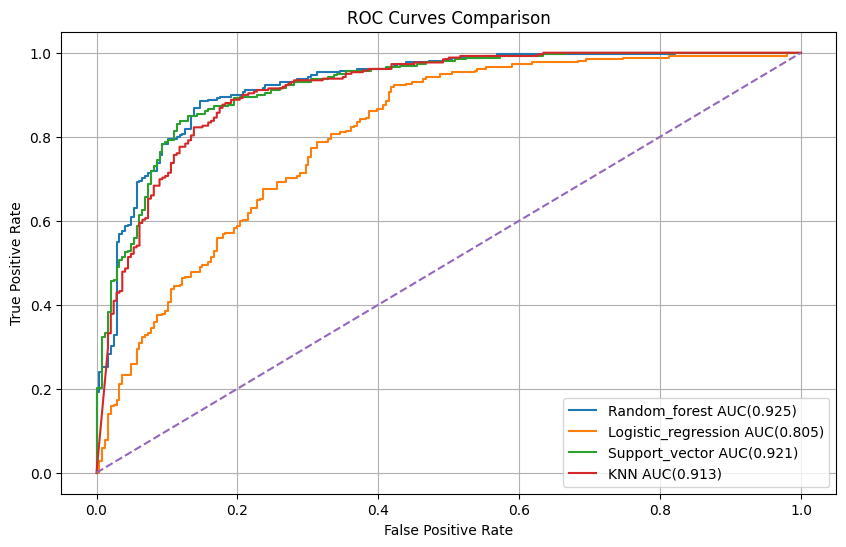

In [102]:
models = [
    {
        'label': 'Random_forest',
        'model': KCV_rf
    },

    {
        'label': 'Logistic_regression',
        'model': KCV_lr  
    },
    
    {
        'label': 'Support_vector',
        'model': KCV_svc
    },

    {
        'label': 'KNN',
        'model': KCV_knn
    },
]

plt.figure(figsize=(10,6))

for m in models:
    model = m['model']
    label = m['label']

    model.fit(X_train_processed, y_train)

    final_est = (
        model.named_steps[list(model.named_steps)[-1]]
        if hasattr(model, "named_steps") else model
    )

    if hasattr(final_est, "predict_proba"):
        y_score = model.predict_proba(X_test_processed)[:, 1]
    else:
        y_score = model.decision_function(X_test_processed)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = roc_auc_score(y_test, y_score)

    plt.plot(fpr, tpr, label=f'{label} AUC({roc_auc:.3f})')


plt.plot([0, 1], [0, 1], "--") #dumb classifier
plt.legend()
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.grid(True)
plt.show()

#### Model performance

Out of all the models, it seems like HGB-RF-SVC did the best at the task. Now we can try to get even better results by combining the classifiers using a voting or stacking classifier.

In [ ]:
best_rf = KCV_rf.best_estimator_
best_lr = KCV_lr.best_estimator_
best_svc = KCV_svc.best_estimator_
best_hgclf = KCV_hg.best_estimator_
best_knn = KCV_knn.best_estimator_

#Lets try a voting classifier

voting_clf = VotingClassifier(estimators=[('lr', best_lr), ('rf', best_rf), ('svc', best_svc), ('hgclf', best_hgclf)], voting='hard')

In [119]:
voting_clf.fit(X_train_processed, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('rf', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'hard'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"with_centering with_centering: bool, default=TrueIf `True`, center the data before scaling.This will cause :meth:`transform` to raise an exception when attemptedon sparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_scaling with_scaling: bool, default=TrueIf `True`, scale the data to interquartile range.",True
,"quantile_range quantile_range: tuple (q_min, q_max), 0.0 < q_min < q_max < 100.0, default=(25.0, 75.0)Quantile range used to calculate `scale_`. By default this is equal tothe IQR, i.e., `q_min` is the first quantile and `q_max` is the thirdquantile... versionadded:: 0.18","(25.0, ...)"
,"copy copy: bool, default=TrueIf `False`, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"unit_variance unit_variance: bool, default=FalseIf `True`, scale data so that normally distributed features have avariance of 1. In general, if the difference between the x-values of`q_max` and `q_min` for a standard normal distribution is greaterthan 1, the dataset will be scaled down. If less than 1, the datasetwill be scaled up... versionadded:: 0.24",False


In [120]:
print(classification_report(y_test, voting_clf.predict(X_test_processed)))

              precision    recall  f1-score   support

           0       0.89      0.81      0.85       246
           1       0.84      0.90      0.87       259

    accuracy                           0.86       505
   macro avg       0.86      0.86      0.86       505
weighted avg       0.86      0.86      0.86       505



In [ ]:
#Then a stacking classifier

stk_clf = StackingClassifier(estimators=[('rf', best_rf), ('svc', best_svc), ('hgclf', best_hgclf), ('knn', best_knn)], final_estimator=best_lr)

In [107]:
stk_clf.fit(X_train_processed, y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('rf', ...), ('svc', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",Pipeline(step...m_state=42))])
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number 

The stacking classifier does a great job with this dataset. 

In [108]:
print(classification_report(y_test, stk_clf.predict(X_test_processed)))

              precision    recall  f1-score   support

           0       0.90      0.82      0.86       246
           1       0.84      0.91      0.88       259

    accuracy                           0.87       505
   macro avg       0.87      0.87      0.87       505
weighted avg       0.87      0.87      0.87       505



<Axes: title={'center': 'confusion matrix for stacking classifier'}>

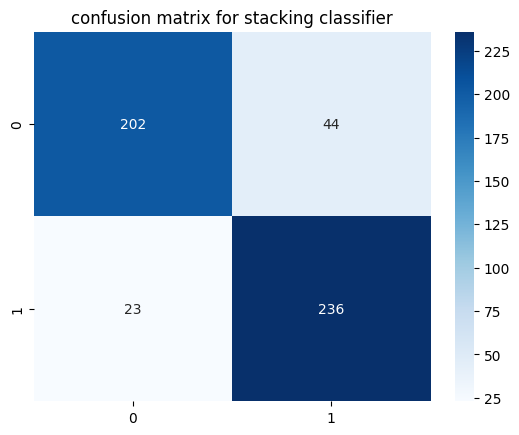

In [109]:
plt.title("Confusion matrix for stacking classifier")
sns.heatmap(confusion_matrix(y_test, stk_clf.predict(X_test_processed)), annot=True, fmt='d', cmap='Blues')

<Axes: title={'center': 'confusion matrix for HGB'}>

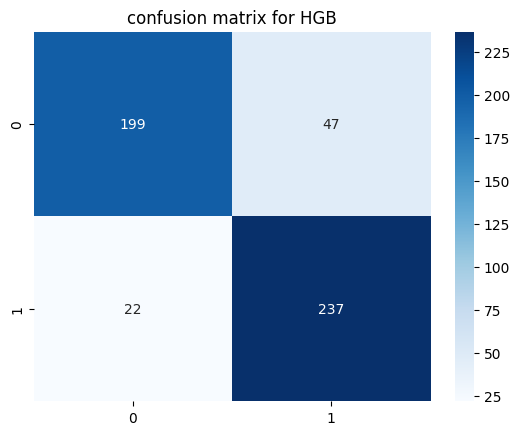

In [121]:
plt.title("Confusion matrix for HGB")
sns.heatmap(confusion_matrix(y_test, KCV_hg.predict(X_test)), annot=True, fmt='d', cmap='Blues')

### Feature  importance 

Finally, let's look at the feature importance for the HGB model. Since it’s a tree-based model, it already has a feature importance function that we can call. Nonetheless, it’s better to do a permutation importance to actually understand the true value of the features. Planet_radius has a high score as expected. The problem with feature importance is that it only indicates how much a feature impacts the model, not by what relationship. To understand this, we need to use a library called shap.

<BarContainer object of 10 artists>

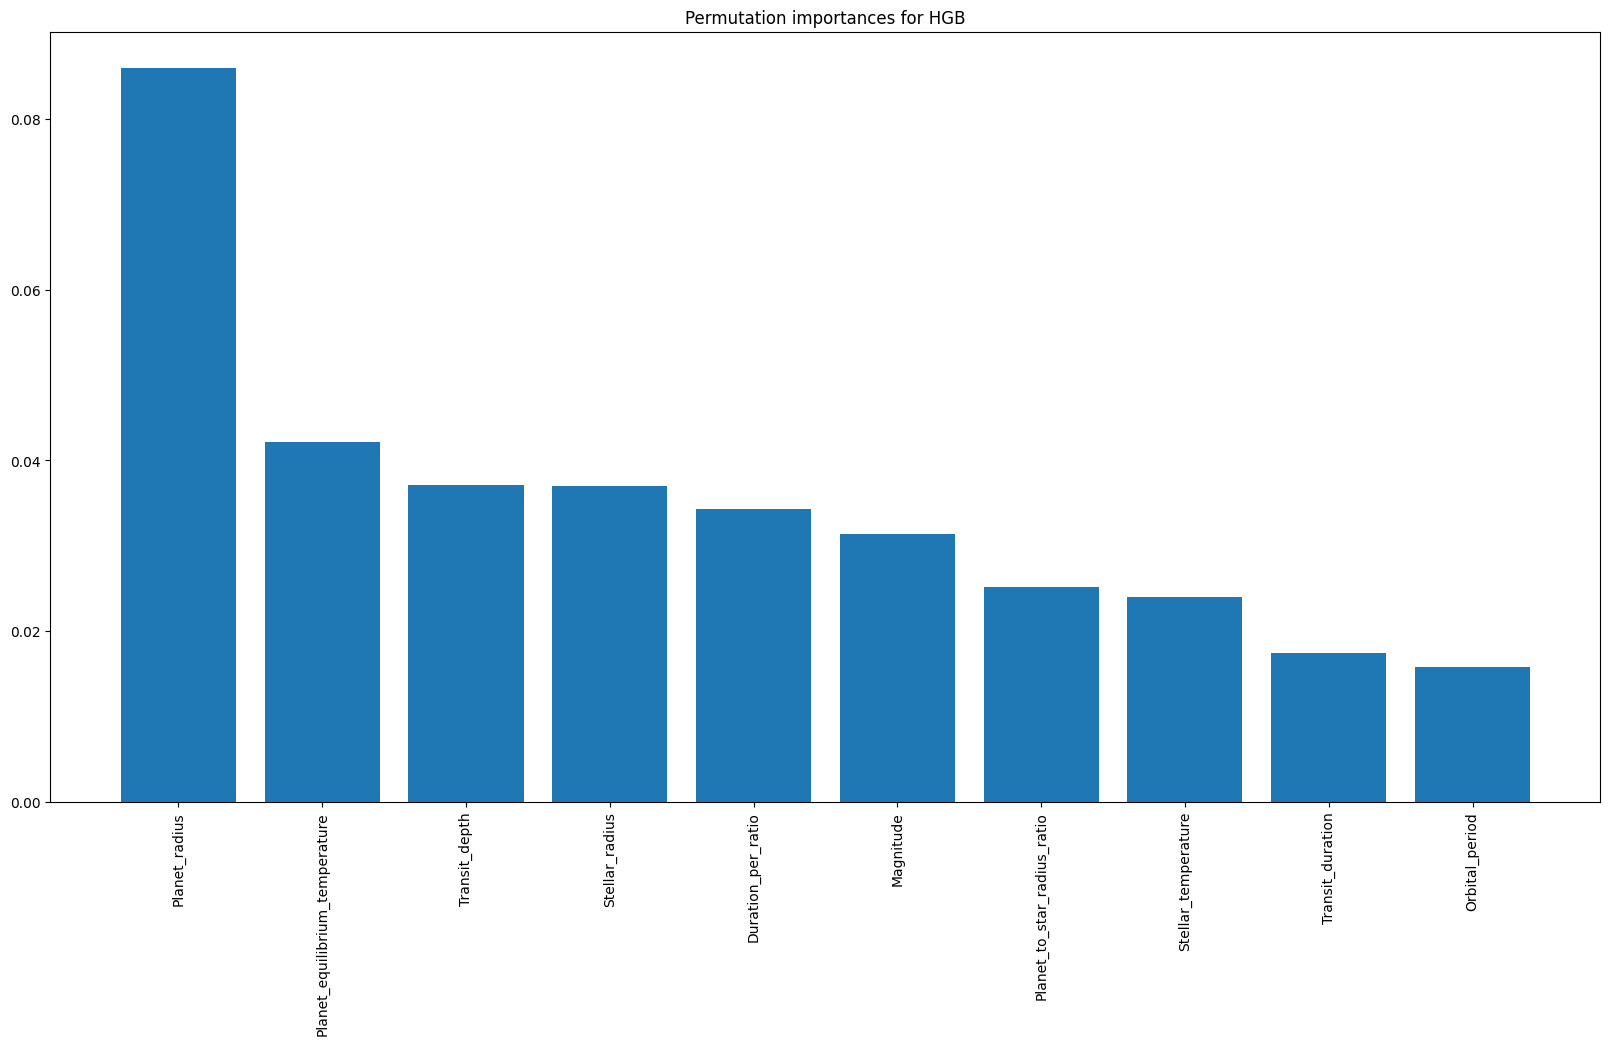

In [122]:
from sklearn.inspection import permutation_importance

r = permutation_importance(
    KCV_hg.best_estimator_,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="average_precision"
)

perm_importance = pd.Series(
    r.importances_mean,
    index=X_test_processed.columns
).sort_values(ascending=False)

plt.figure(figsize=(20,10))
plt.title("Permutation importances for HGB")
plt.tick_params(axis='x', labelrotation=90)
plt.bar(perm_importance.index, perm_importance)

### Using shap to understand the complex reletionships in the model

In [123]:
import shap

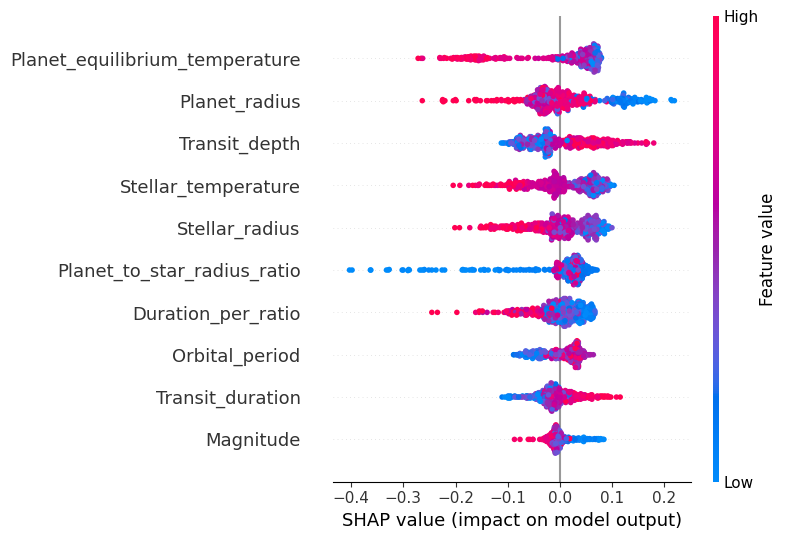

In [126]:
#this is the standard way of importing a tree based model into shap

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer(X_test_processed)

#with the summary plot command we generate a beutiful graph that tells how a reletionship impacts the model decision-making
shap.summary_plot(
    shap_values.values[:, :, 1],
    X_test_processed
)

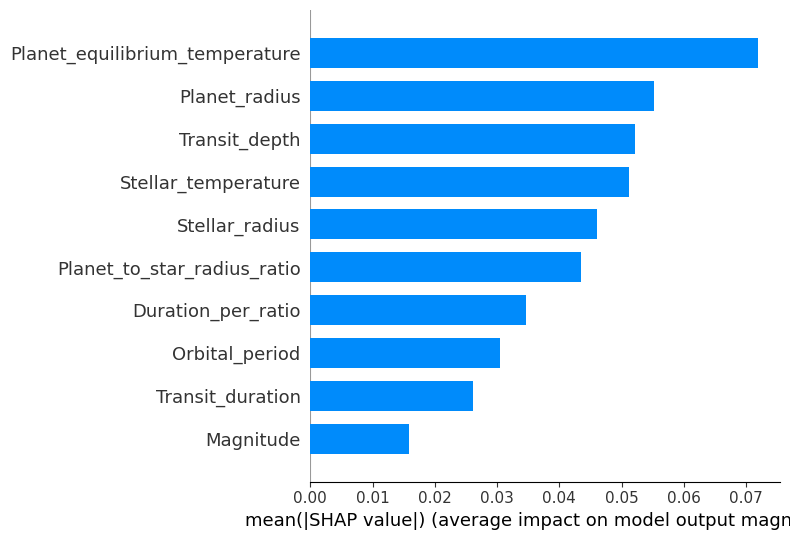

In [127]:
#a summary plot is just a feature importance graph

shap.summary_plot(
    shap_values.values[:, :, 1],
    X_test_processed,
    plot_type="bar"
)

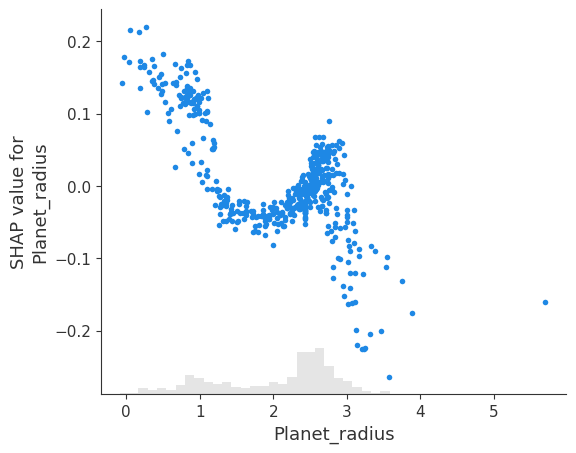

In [131]:
#in my opinion the best chart of the shap library is the scatter plot, since it allows us to visualize directly the reletionships

shap.plots.scatter(shap_values[:, "Planet_radius", 1])

Now we understand that a small radius means the model is more confident that it's a real planet. Then, there's a fall approximately where the radius valley is located, followed by a rise again where the Hot-Jupiters are located. Finally, it falls down again where there are false positives, like Eclipsing binaries.

From now on, we can explore all the different features and understand their relationship with the model's decision-making.

### Conclusions

While this model doesn’t directly have access to the raw light curves, it can still leverage
derived photometric and stellar parameters to effectively distinguish between confirmed planets
and false positives.

The analysis showed that tree-based models — particularly HistGradientBoostingClassifier —
handle the missing values and skewed distributions in this dataset well, even without imputation.
After log-scaling the features and engineering two new variables (planet-to-star radius ratio
and transit duration per orbital period), the separability between the two classes improved
significantly.

Among all tested approaches, the stacking classifier delivered the best overall performance,
combining the strengths of Random Forest, SVC, HGB, and KNN with Logistic Regression as the
final estimator. The SHAP analysis added an important layer of interpretability.

Future works: this analysis showed a supervised learning approach, but there's also the possibility of solving a clustering problem by trying to divide all the different types of exoplanets. Moreover, this effort will probably be updated in the future.  

Limitations worth noting: the dataset is relatively small (~2,500 observations), which constrains
generalization. Future work could incorporate additional TESS sectors and raw light curve features.
extracted via tools like lightkurve, or deep learning approaches that operate directly on the
flux time series.